In [16]:
# Cell - Configuration and parameters

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# ── Periods ───────────────────────────────────────────────────────────────────
IS_START  = '2018-01-01'
IS_END    = '2022-12-31'
OOS_START = '2023-01-01'
OOS_END   = '2025-12-31'

# ── Portfolio Parameters ──────────────────────────────────────────────────────
TOP_N          = 3
SAFE_HAVEN     = 'GLD'
REBALANCE_FREQ = 'W-FRI'
RSI_PERIOD     = 14
RSI_THRESHOLD  = 50

# ── Transaction Cost Model ────────────────────────────────────────────────────
CRYPTO_TICKERS         = {'BTC-USD', 'ETH-USD', 'SOL-USD', 'BNB-USD'}
TQQQ_DECAY_BPS_PER_DAY = 0.7 / 10_000

def one_way_cost(ticker: str) -> float:
    if ticker in CRYPTO_TICKERS:
        return 0.0030
    return 0.0011

# ── Best ensemble logic per asset ─────────────────────────────────────────────
BEST_LOGIC = {
    'SMH':     ('OR',       'AND'),
    'GDX':     ('OR',       'OR'),
    'DGRW':    ('AND',      'OR'),
    'DXJ':     ('OR',       'OR'),
    'BOTZ':    ('AND',      'OR'),
    'LIT':     ('AND',      'OR'),
    'URNM':    ('OR',       'OR'),
    'ARKK':    ('AND',      'OR'),
    'ARKG':    ('OR',       'OR'),
    'HACK':    ('AND',      'OR'),
    'BLOK':    ('OR',       'OR'),
    'QTUM':    ('AND',      'OR'),
    'AIRR':    ('OR',       'OR'),
    'IRBO':    ('OR',       'OR'),
    'MTUM':    ('OR',       'AND'),
    'DBMF':    ('OR',       'AND'),
    'KMLM':    ('AND',      'OR'),
    'GLD':     ('AND',      'OR'),
    'SPY':     ('OR',       'AND'),
    'QQQ':     ('AND',      'OR'),
    'TQQQ':    ('AND',      'AND'),
    'BTC-USD': ('AND',      'OR'),
    'SOL-USD': ('AND',      'AND'),
    'ETH-USD': ('AND',      'OR'),
    'BNB-USD': ('OR',       'OR'),
    'MSFT':    ('OR',       'AND'),
    'AAPL':    ('OR',       'OR'),
    'NVDA':    ('OR',       'OR'),
    'XLE':     ('AND',      'OR'),
    'AMLP':    ('OR',       'OR'),
    'XLF':     ('AND',      'OR'),
    'KRE':     ('OR',       'OR'),
    'XLV':     ('OR',       'OR'),
    'XBI':     ('OR',       'OR'),
    'XLI':     ('AND',      'OR'),
    'XLB':     ('AND',      'OR'),
    'XLP':     ('AND',      'OR'),
    'XLY':     ('OR',       'AND'),
    'VNQ':     ('AND',      'OR'),
    'XLRE':    ('OR',       'AND'),
    'TLT':     ('OR',       'AND'),
    'HYG':     ('OR',       'AND'),
    'EFA':     ('AND',      'OR'),
    'VGK':     ('AND',      'AND'),
    '^NSEI':   ('AND',      'OR'),
}

TICKERS = list(BEST_LOGIC.keys())

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        10,
})

print('Parameters defined ✓')
print(f'Universe : {TICKERS}')
print(f'TOP_N={TOP_N}  SAFE_HAVEN={SAFE_HAVEN}  RSI_PERIOD={RSI_PERIOD}  RSI_THRESHOLD={RSI_THRESHOLD}')
print('\nTransaction cost model:')
for t in TICKERS:
    note = ' + 0.7 bp/day holding decay' if t == 'TQQQ' else ''
    print(f'  {t:<10}: {one_way_cost(t)*10_000:.0f} bps one-way{note}')

Parameters defined ✓
Universe : ['SMH', 'GDX', 'DGRW', 'DXJ', 'BOTZ', 'LIT', 'URNM', 'ARKK', 'ARKG', 'HACK', 'BLOK', 'QTUM', 'AIRR', 'IRBO', 'MTUM', 'DBMF', 'KMLM', 'GLD', 'SPY', 'QQQ', 'TQQQ', 'BTC-USD', 'SOL-USD', 'ETH-USD', 'BNB-USD', 'MSFT', 'AAPL', 'NVDA', 'XLE', 'AMLP', 'XLF', 'KRE', 'XLV', 'XBI', 'XLI', 'XLB', 'XLP', 'XLY', 'VNQ', 'XLRE', 'TLT', 'HYG', 'EFA', 'VGK', '^NSEI']
TOP_N=3  SAFE_HAVEN=GLD  RSI_PERIOD=14  RSI_THRESHOLD=50

Transaction cost model:
  SMH       : 11 bps one-way
  GDX       : 11 bps one-way
  DGRW      : 11 bps one-way
  DXJ       : 11 bps one-way
  BOTZ      : 11 bps one-way
  LIT       : 11 bps one-way
  URNM      : 11 bps one-way
  ARKK      : 11 bps one-way
  ARKG      : 11 bps one-way
  HACK      : 11 bps one-way
  BLOK      : 11 bps one-way
  QTUM      : 11 bps one-way
  AIRR      : 11 bps one-way
  IRBO      : 11 bps one-way
  MTUM      : 11 bps one-way
  DBMF      : 11 bps one-way
  KMLM      : 11 bps one-way
  GLD       : 11 bps one-way
  SPY      

In [17]:
# Cell 2 — Data Download & Parsing
raw = yf.download(TICKERS, start='2017-01-01', end=OOS_END, auto_adjust=True)

price_data = {}
for ticker in TICKERS:
    try:
        df = pd.DataFrame({
            'Open':   raw['Open'][ticker],
            'High':   raw['High'][ticker],
            'Low':    raw['Low'][ticker],
            'Close':  raw['Close'][ticker],
            'Volume': raw['Volume'][ticker],
        }).dropna()
        price_data[ticker] = df
        print(f'  {ticker}: {len(df)} bars  ({df.index[0].date()} → {df.index[-1].date()})')
    except Exception as e:
        print(f'  {ticker}: FAILED — {e}')

print(f'\nLoaded {len(price_data)} tickers ✓')

# ── OPTION C: Build the merged full calendar ───────────────────────────────────
# Union of all trading days across equity and crypto.
# Equity assets trade ~252 days/yr; crypto trades 365 days/yr.
# The merged index contains every day that ANY asset has a price.
# Equity returns will be 0 on non-trading days (correct: markets closed).
# Crypto returns will reflect actual weekend moves (correct: they trade).

all_native_indices = [df.index for df in price_data.values()]
FULL_INDEX = all_native_indices[0]
for idx in all_native_indices[1:]:
    FULL_INDEX = FULL_INDEX.union(idx)
FULL_INDEX = FULL_INDEX.sort_values()

# Equity-only days kept available for diagnostics
equity_tickers_list = [t for t in TICKERS if t not in CRYPTO_TICKERS and t in price_data]
_equity_union = price_data[equity_tickers_list[0]].index
for t in equity_tickers_list[1:]:
    _equity_union = _equity_union.union(price_data[t].index)
EQUITY_TRADING_DAYS = _equity_union.sort_values()

print(f'\nFULL_INDEX  : {len(FULL_INDEX)} days  '
      f'({FULL_INDEX[0].date()} → {FULL_INDEX[-1].date()})')
print(f'Equity days : {len(EQUITY_TRADING_DAYS)} days')
print(f'Extra crypto days (weekends/holidays): '
      f'{len(FULL_INDEX) - len(EQUITY_TRADING_DAYS)}')

[*********************100%***********************]  45 of 45 completed


  SMH: 2261 bars  (2017-01-03 → 2025-12-30)
  GDX: 2261 bars  (2017-01-03 → 2025-12-30)
  DGRW: 2261 bars  (2017-01-03 → 2025-12-30)
  DXJ: 2261 bars  (2017-01-03 → 2025-12-30)
  BOTZ: 2261 bars  (2017-01-03 → 2025-12-30)
  LIT: 2261 bars  (2017-01-03 → 2025-12-30)
  URNM: 1526 bars  (2019-12-04 → 2025-12-30)
  ARKK: 2261 bars  (2017-01-03 → 2025-12-30)
  ARKG: 2261 bars  (2017-01-03 → 2025-12-30)
  HACK: 2261 bars  (2017-01-03 → 2025-12-30)
  BLOK: 1994 bars  (2018-01-25 → 2025-12-30)
  QTUM: 1840 bars  (2018-09-05 → 2025-12-30)
  AIRR: 2261 bars  (2017-01-03 → 2025-12-30)
  IRBO: 1888 bars  (2018-06-26 → 2025-12-30)
  MTUM: 2261 bars  (2017-01-03 → 2025-12-30)
  DBMF: 1672 bars  (2019-05-08 → 2025-12-30)
  KMLM: 1275 bars  (2020-12-02 → 2025-12-30)
  GLD: 2261 bars  (2017-01-03 → 2025-12-30)
  SPY: 2261 bars  (2017-01-03 → 2025-12-30)
  QQQ: 2261 bars  (2017-01-03 → 2025-12-30)
  TQQQ: 2261 bars  (2017-01-03 → 2025-12-30)
  BTC-USD: 3286 bars  (2017-01-01 → 2025-12-30)
  SOL-USD: 209

In [18]:

# Cell 3 — Define Indicators (Option C)
# All signals end with .shift(1) as their final operation.
# Indicators are computed on each asset's native price series
# so no calendar distortion occurs here.

def compute_atr(high, low, close, period):
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs(),
    ], axis=1).max(axis=1)
    atr = np.full(len(tr), np.nan)
    atr[period - 1] = tr.iloc[:period].mean()
    alpha = 1.0 / period
    for i in range(period, len(tr)):
        atr[i] = atr[i-1] * (1 - alpha) + tr.iloc[i] * alpha
    return pd.Series(atr, index=close.index)


def supertrend_signal(high, low, close, atr_period, multiplier):
    hl2 = (high + low) / 2.0
    atr = compute_atr(high, low, close, atr_period)
    basic_upper = hl2 + multiplier * atr
    basic_lower = hl2 - multiplier * atr
    n  = len(close)
    fu = np.full(n, np.nan)
    fl = np.full(n, np.nan)
    direction = np.full(n, np.nan)
    c  = close.values
    bu = basic_upper.values
    bl = basic_lower.values
    seed = atr_period
    fu[seed] = bu[seed]
    fl[seed] = bl[seed]
    direction[seed] = 1 if c[seed] > bu[seed] else -1
    for i in range(seed + 1, n):
        if np.isnan(bu[i]):
            continue
        fu[i] = bu[i] if (bu[i] < fu[i-1] or c[i-1] > fu[i-1]) else fu[i-1]
        fl[i] = bl[i] if (bl[i] > fl[i-1] or c[i-1] < fl[i-1]) else fl[i-1]
        if   c[i] > fu[i-1]: direction[i] =  1
        elif c[i] < fl[i-1]: direction[i] = -1
        else:                 direction[i] = direction[i-1]
    raw_signal = (pd.Series(direction, index=close.index) == 1).astype(int)
    return raw_signal.shift(1).fillna(0).astype(int)


def kama_signal(close, er_period, fast_period, slow_period):
    fast_sc = 2 / (fast_period + 1)
    slow_sc = 2 / (slow_period + 1)
    c = close.values
    n = len(c)
    kama = np.full(n, np.nan)
    kama[er_period - 1] = c[er_period - 1]
    for i in range(er_period, n):
        direction_  = abs(c[i] - c[i - er_period])
        volatility  = np.sum(np.abs(np.diff(c[i - er_period: i + 1])))
        er = direction_ / volatility if volatility != 0 else 0
        sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
        kama[i] = kama[i-1] + sc * (c[i] - kama[i-1])
    kama_s   = pd.Series(kama, index=close.index)
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, n):
        if pd.isna(kama_s.iloc[i-1]):
            continue
        if state == 0:
            if close.iloc[i] > kama_s.iloc[i-1]: state = 1
        else:
            if close.iloc[i] < kama_s.iloc[i-1]: state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


def rsi_window_signal(close, rsi_period, window):
    delta    = close.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    rsi      = 100 - (100 / (1 + rs))
    upper    = rsi.rolling(window).quantile(0.80)
    lower    = rsi.rolling(window).quantile(0.20)
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(rsi)):
        up = upper.iloc[i-1]
        lo = lower.iloc[i-1]
        if pd.isna(up) or pd.isna(lo):
            position.iloc[i] = state
            continue
        if state == 0:
            if rsi.iloc[i] > up: state = 1
        else:
            if rsi.iloc[i] < lo: state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


def triple_ema_signal(close, fast, medium, slow):
    ef = close.ewm(span=fast,   adjust=False).mean()
    em = close.ewm(span=medium, adjust=False).mean()
    es = close.ewm(span=slow,   adjust=False).mean()
    bullish = ((ef > em) & (em > es)).astype(int)
    return bullish.shift(1).fillna(0).astype(int)


def macd_signal(close, fast, slow, signal):
    ema_fast    = close.ewm(span=fast,   adjust=False).mean()
    ema_slow    = close.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    raw = (macd_line > signal_line).astype(int)
    return raw.shift(1).fillna(0).astype(int)


def donchian_signal(close, high, low, entry_period, exit_period):
    upper_entry = high.rolling(entry_period).max()
    lower_exit  = low.rolling(exit_period).min()
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(close)):
        if state == 0:
            if close.iloc[i] > upper_entry.iloc[i-1]: state = 1
        else:
            if close.iloc[i] < lower_exit.iloc[i-1]:  state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


def bollinger_signal(close, period, mult):
    middle = close.rolling(window=period).mean()
    std    = close.rolling(window=period).std(ddof=0)
    lower  = middle - mult * std
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(close)):
        if pd.isna(lower.iloc[i-1]):
            continue
        if state == 0:
            if close.iloc[i-1] > lower.iloc[i-1] and close.iloc[i] <= lower.iloc[i]:
                state = 1
        else:
            if close.iloc[i-1] < middle.iloc[i-1] and close.iloc[i] >= middle.iloc[i]:
                state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


print('Indicator library defined ✓  (all signals end with .shift(1))')

Indicator library defined ✓  (all signals end with .shift(1))


In [19]:
# Cell 4 — Indicator Library

def build_signals(ticker, df):
    c, h, l = df['Close'], df['High'], df['Low']
    configs = {
        'SMH':     [('3EMA(10,56,120)',   lambda: triple_ema_signal(c, 10, 56, 120)),
                    ('KAMA(27,18,24)',    lambda: kama_signal(c, 27, 18, 24))],
        'GDX':     [('KAMA(18,10,18)',    lambda: kama_signal(c, 18, 10, 18)),
                    ('3EMA(10,56,120)',   lambda: triple_ema_signal(c, 10, 56, 120))],
        'DGRW':    [('KAMA(21,4,10)',     lambda: kama_signal(c, 21, 4, 10)),
                    ('3EMA(10,64,132)',   lambda: triple_ema_signal(c, 10, 64, 132))],
        'DXJ':     [('3EMA(5,104,120)',   lambda: triple_ema_signal(c, 5, 104, 120)),
                    ('KAMA(25,32,38)',    lambda: kama_signal(c, 25, 32, 38))],
        'BOTZ':    [('MACD(5,218,77)',    lambda: macd_signal(c, 5, 218, 77)),
                    ('KAMA(15,4,60)',     lambda: kama_signal(c, 15, 4, 60))],
        'LIT':     [('MACD(9,94,43)',     lambda: macd_signal(c, 9, 94, 43)),
                    ('KAMA(6,4,12)',      lambda: kama_signal(c, 6, 4, 12))],
        'URNM':    [('KAMA(4,6,12)',      lambda: kama_signal(c, 4, 6, 12)),
                    ('MACD(5,220,47)',    lambda: macd_signal(c, 5, 220, 47))],
        'ARKK':    [('MACD(15,154,115)', lambda: macd_signal(c, 15, 154, 115)),
                    ('KAMA(27,4,22)',     lambda: kama_signal(c, 27, 4, 22))],
        'ARKG':    [('KAMA(21,4,14)',     lambda: kama_signal(c, 21, 4, 14)),
                    ('3EMA(5,48,240)',    lambda: triple_ema_signal(c, 5, 48, 240))],
        'HACK':    [('KAMA(2,6,16)',      lambda: kama_signal(c, 2, 6, 16)),
                    ('3EMA(5,56,228)',    lambda: triple_ema_signal(c, 5, 56, 228))],
        'BLOK':    [('MACD(5,210,187)',   lambda: macd_signal(c, 5, 210, 187)),
                    ('KAMA(4,4,16)',      lambda: kama_signal(c, 4, 4, 16))],
        'QTUM':    [('MACD(5,130,35)',    lambda: macd_signal(c, 5, 130, 35)),
                    ('3EMA(5,40,156)',    lambda: triple_ema_signal(c, 5, 40, 156))],
        'AIRR':    [('MACD(11,194,73)',   lambda: macd_signal(c, 11, 194, 73)),
                    ('KAMA(8,4,28)',      lambda: kama_signal(c, 8, 4, 28))],
        'IRBO':    [('MACD(5,108,35)',    lambda: macd_signal(c, 5, 108, 35)),
                    ('KAMA(3,4,18)',      lambda: kama_signal(c, 3, 4, 18))],
        'MTUM':    [('MACD(9,122,39)',    lambda: macd_signal(c, 9, 122, 39)),
                    ('3EMA(5,128,240)',   lambda: triple_ema_signal(c, 5, 128, 240))],
        'DBMF':    [('MACD(11,228,41)',   lambda: macd_signal(c, 11, 228, 41)),
                    ('3EMA(10,40,240)',   lambda: triple_ema_signal(c, 10, 40, 240))],
        'KMLM':    [('MACD(5,68,53)',     lambda: macd_signal(c, 5, 68, 53)),
                    ('3EMA(5,40,132)',    lambda: triple_ema_signal(c, 5, 40, 132))],
        'GLD':     [('MACD(53,80,51)',    lambda: macd_signal(c, 53, 80, 51)),
                    ('3EMA(15,88,120)',   lambda: triple_ema_signal(c, 15, 88, 120))],
        'SPY':     [('3EMA(5,88,192)',    lambda: triple_ema_signal(c, 5, 88, 192)),
                    ('MACD(9,94,39)',     lambda: macd_signal(c, 9, 94, 39))],
        'QQQ':     [('KAMA(11,12,20)',    lambda: kama_signal(c, 11, 12, 20)),
                    ('MACD(7,226,37)',    lambda: macd_signal(c, 7, 226, 37))],
        'TQQQ':    [('MACD(7,62,47)',     lambda: macd_signal(c, 7, 62, 47))],
        'BTC-USD': [('MACD(5,58,39)',     lambda: macd_signal(c, 5, 58, 39)),
                    ('KAMA(8,12,16)',     lambda: kama_signal(c, 8, 12, 16))],
        'SOL-USD': [('MACD(7,146,35)',    lambda: macd_signal(c, 7, 146, 35))],
        'ETH-USD': [('MACD(15,48,35)',    lambda: macd_signal(c, 15, 48, 35)),
                    ('KAMA(13,4,12)',     lambda: kama_signal(c, 13, 4, 12))],
        'BNB-USD': [('KAMA(11,6,10)',     lambda: kama_signal(c, 11, 6, 10)),
                    ('MACD(5,200,47)',    lambda: macd_signal(c, 5, 200, 47))],
        'MSFT':    [('MACD(9,178,87)',    lambda: macd_signal(c, 9, 178, 87)),
                    ('KAMA(27,6,36)',     lambda: kama_signal(c, 27, 6, 36))],
        'AAPL':    [('MACD(25,50,37)',    lambda: macd_signal(c, 25, 50, 37)),
                    ('KAMA(6,4,24)',      lambda: kama_signal(c, 6, 4, 24))],
        'NVDA':    [('KAMA(24,4,40)',     lambda: kama_signal(c, 24, 4, 40)),
                    ('MACD(5,92,81)',     lambda: macd_signal(c, 5, 92, 81))],
        'XLE':     [('KAMA(5,56,156)',    lambda: kama_signal(c, 5, 56, 156)),
                    ('MACD(5,48,35)',     lambda: macd_signal(c, 5, 48, 35))],
        'AMLP':    [('KAMA(2,4,30)',      lambda: kama_signal(c, 2, 4, 30)),
                    ('MACD(5,62,39)',     lambda: macd_signal(c, 5, 62, 39))],
        'XLF':     [('KAMA(3,4,18)',      lambda: kama_signal(c, 3, 4, 18)),
                    ('MACD(41,108,39)',   lambda: macd_signal(c, 41, 108, 39))],
        'KRE':     [('KAMA(5,6,16)',      lambda: kama_signal(c, 5, 6, 16)),
                    ('3EMA(5,40,156)',    lambda: triple_ema_signal(c, 5, 40, 156))],
        'XLV':     [('KAMA(3,4,38)',      lambda: kama_signal(c, 3, 4, 38)),
                    ('MACD(9,56,41)',     lambda: macd_signal(c, 9, 56, 41))],
        'XBI':     [('MACD(13,224,121)', lambda: macd_signal(c, 13, 224, 121)),
                    ('KAMA(2,6,18)',      lambda: kama_signal(c, 2, 6, 18))],
        'XLI':     [('KAMA(4,6,14)',      lambda: kama_signal(c, 4, 6, 14)),
                    ('3EMA(10,48,120)',   lambda: triple_ema_signal(c, 10, 48, 120))],
        'XLB':     [('MACD(33,100,37)',   lambda: macd_signal(c, 33, 100, 37)),
                    ('KAMA(26,4,10)',     lambda: kama_signal(c, 26, 4, 10))],
        'XLP':     [('KAMA(21,4,14)',     lambda: kama_signal(c, 21, 4, 14)),
                    ('3EMA(5,112,168)',   lambda: triple_ema_signal(c, 5, 112, 168))],
        'XLY':     [('MACD(25,46,35)',    lambda: macd_signal(c, 25, 46, 35)),
                    ('3EMA(10,48,144)',   lambda: triple_ema_signal(c, 10, 48, 144))],
        'VNQ':     [('MACD(9,164,143)',   lambda: macd_signal(c, 9, 164, 143)),
                    ('KAMA(10,2,30)',     lambda: kama_signal(c, 10, 2, 30))],
        'XLRE':    [('KAMA(27,6,32)',     lambda: kama_signal(c, 27, 6, 32)),
                    ('3EMA(5,40,156)',    lambda: triple_ema_signal(c, 5, 40, 156))],
        'TLT':     [('3EMA(5,48,204)',    lambda: triple_ema_signal(c, 5, 48, 204)),
                    ('MACD(11,206,35)',   lambda: macd_signal(c, 11, 206, 35))],
        'HYG':     [('KAMA(28,18,20)',    lambda: kama_signal(c, 28, 18, 20)),
                    ('3EMA(5,56,120)',    lambda: triple_ema_signal(c, 5, 56, 120))],
        'EFA':     [('KAMA(4,8,30)',      lambda: kama_signal(c, 4, 8, 30)),
                    ('MACD(5,218,121)',   lambda: macd_signal(c, 5, 218, 121))],
        'VGK':     [('KAMA(17,6,24)',     lambda: kama_signal(c, 17, 6, 24))],
        '^NSEI':   [('3EMA(5,128,240)',   lambda: triple_ema_signal(c, 5, 128, 240)),
                    ('KAMA(2,4,12)',      lambda: kama_signal(c, 2, 4, 12))],
    }
    if ticker not in configs:
        return {}
    signals = {}
    for label, fn in configs[ticker]:
        try:
            signals[label] = fn()
        except Exception as e:
            print(f'  Warning: {ticker} {label} failed — {e}')
    return signals


def apply_logic(signals_arr, mode):
    n = len(signals_arr)
    if mode == 'AND':
        return all(s == 1 for s in signals_arr)
    elif mode == 'OR':
        return any(s == 1 for s in signals_arr)
    elif mode == 'MAJORITY':
        return any(s == 1 for s in signals_arr) if n <= 2 \
               else sum(s == 1 for s in signals_arr) > n / 2
    return False


def run_ensemble(signal_dict, entry_logic, exit_logic):
    labels = list(signal_dict.keys())
    n_ind  = len(labels)
    if n_ind == 0:
        raise ValueError('No signals provided')
    if n_ind == 1:
        return list(signal_dict.values())[0]

    sig_df = pd.DataFrame(signal_dict).fillna(0).astype(int)
    pos    = pd.Series(0, index=sig_df.index, dtype=int)
    state  = 0
    for i in range(len(sig_df)):
        row = sig_df.iloc[i].values
        if state == 0:
            if apply_logic(row, entry_logic): state = 1
        else:
            exit_row = [1 - s for s in row]
            if apply_logic(exit_row, exit_logic): state = 0
        pos.iloc[i] = state
    return pos


print('Signal configs & ensemble engine defined ✓')

Signal configs & ensemble engine defined ✓


In [20]:
# Cell 5 — Signal Configs & Ensemble Engine
# OPTION C CHANGE:
# After computing the position on the asset's native calendar, reindex to
# FULL_INDEX and forward-fill. Equity positions on Sat/Sun carry Friday's
# signal unchanged — markets are closed, no new information. Crypto positions
# are already on a 365-day calendar so ffill is a no-op for them.

print('Building ensemble positions for all assets...')

all_positions = {}
all_closes    = {}

for ticker in TICKERS:
    if ticker not in price_data:
        print(f'  {ticker}: no price data — skipping')
        continue
    df           = price_data[ticker]
    entry, exit_ = BEST_LOGIC[ticker]
    sigs         = build_signals(ticker, df)
    if not sigs:
        print(f'  {ticker}: no signals built — skipping')
        continue
    pos = run_ensemble(sigs, entry, exit_)

    # Reindex to the merged full calendar and forward-fill held positions.
    # ffill() propagates Friday's signal through Saturday and Sunday for
    # equity assets; fillna(0) handles the pre-warmup period.
    pos_full = pos.reindex(FULL_INDEX).ffill().fillna(0).astype(int)
    all_positions[ticker] = pos_full

    # Close series: reindex to FULL_INDEX and ffill.
    # Equity closes are flat over weekends (correct — no trading).
    # Crypto closes are real every day.
    all_closes[ticker] = price_data[ticker]['Close'].reindex(FULL_INDEX).ffill()

    print(f'  {ticker}: done  (entry={entry}, exit={exit_}, '
          f'full_index bars={len(pos_full)})')

print(f'\nPositions built for {len(all_positions)} assets ✓')

Building ensemble positions for all assets...
  SMH: done  (entry=OR, exit=AND, full_index bars=3286)
  GDX: done  (entry=OR, exit=OR, full_index bars=3286)
  DGRW: done  (entry=AND, exit=OR, full_index bars=3286)
  DXJ: done  (entry=OR, exit=OR, full_index bars=3286)
  BOTZ: done  (entry=AND, exit=OR, full_index bars=3286)
  LIT: done  (entry=AND, exit=OR, full_index bars=3286)
  URNM: done  (entry=OR, exit=OR, full_index bars=3286)
  ARKK: done  (entry=AND, exit=OR, full_index bars=3286)
  ARKG: done  (entry=OR, exit=OR, full_index bars=3286)
  HACK: done  (entry=AND, exit=OR, full_index bars=3286)
  BLOK: done  (entry=OR, exit=OR, full_index bars=3286)
  QTUM: done  (entry=AND, exit=OR, full_index bars=3286)
  AIRR: done  (entry=OR, exit=OR, full_index bars=3286)
  IRBO: done  (entry=OR, exit=OR, full_index bars=3286)
  MTUM: done  (entry=OR, exit=AND, full_index bars=3286)
  DBMF: done  (entry=OR, exit=AND, full_index bars=3286)
  KMLM: done  (entry=AND, exit=OR, full_index bars=32

In [21]:
# Cell 6 — Position Building
# OPTION C CHANGE:
# Removed the equity_day_mask that previously dropped weekend rows.
# Cumulative returns are now built on FULL_INDEX. Because all_closes values
# are already ffill'd, pct_change() on equity assets returns 0 on weekends —
# no phantom returns. Crypto returns are real every day. The RSI lag shift
# is retained. On weekends, equity RSI is unchanged (flat price → no update),
# which is correct — no new signal should fire on a closed market.

def compute_rsi_series(series, period):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def build_rsi_ranks(all_closes, period, threshold):
    cum_rets = {}
    for ticker, close in all_closes.items():
        daily = close.pct_change().fillna(0)
        cum_rets[ticker] = (1 + daily).cumprod()

    cum_df = pd.DataFrame(cum_rets)

    rsi_df = pd.DataFrame({
        ticker: compute_rsi_series(cum_df[ticker], period)
        for ticker in cum_df.columns
    })

    rsi_lagged = rsi_df.shift(1)  # today's rank uses yesterday's RSI

    ranks = pd.DataFrame(index=rsi_lagged.index,
                         columns=rsi_lagged.columns, dtype=float)
    for date in rsi_lagged.index:
        row      = rsi_lagged.loc[date]
        eligible = row[row >= threshold]
        if eligible.empty:
            ranks.loc[date] = np.nan
        else:
            ranked = eligible.rank(ascending=False, method='first')
            ranks.loc[date, ranked.index] = ranked.values

    return ranks, rsi_lagged


print('Building RSI momentum ranks on merged full calendar...')
rsi_ranks, rsi_values = build_rsi_ranks(all_closes, RSI_PERIOD, RSI_THRESHOLD)
print(f'RSI ranks built: {rsi_ranks.shape[0]} dates × {rsi_ranks.shape[1]} assets ✓')
print('\nSample ranks (last 5 rows):')
display(rsi_ranks.tail())

Building RSI momentum ranks on merged full calendar...
RSI ranks built: 3286 dates × 45 assets ✓

Sample ranks (last 5 rows):


,SMH,GDX,DGRW,DXJ,BOTZ,LIT,URNM,ARKK,ARKG,HACK,...,XLB,XLP,XLY,VNQ,XLRE,TLT,HYG,EFA,VGK,^NSEI
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-26,24.0000,3.0000,15.0000,22.0000,21.0000,6.0000,27.0000,34.0000,35.0000,NaN,...,4.0000,37.0000,13.0000,33.0000,31.0000,32.0000,8.0000,9.0000,7.0000,26.0000
2025-12-27,19.0000,3.0000,11.0000,20.0000,24.0000,4.0000,28.0000,NaN,NaN,NaN,...,5.0000,32.0000,16.0000,30.0000,27.0000,NaN,10.0000,8.0000,7.0000,33.0000
2025-12-28,19.0000,3.0000,11.0000,20.0000,24.0000,4.0000,28.0000,NaN,NaN,NaN,...,5.0000,32.0000,16.0000,30.0000,27.0000,NaN,10.0000,8.0000,7.0000,33.0000
2025-12-29,19.0000,3.0000,11.0000,20.0000,24.0000,4.0000,28.0000,NaN,NaN,NaN,...,5.0000,32.0000,16.0000,30.0000,27.0000,NaN,10.0000,8.0000,7.0000,33.0000
2025-12-30,14.0000,NaN,10.0000,6.0000,8.0000,19.0000,22.0000,NaN,NaN,NaN,...,5.0000,25.0000,31.0000,16.0000,12.0000,23.0000,1.0000,4.0000,2.0000,NaN


In [22]:
# Cell 7 — Portfolio Weight Construction (FIXED: respects REBALANCE_FREQ)

def build_portfolio_weights(rsi_ranks, all_positions, all_closes,
                             top_n, safe_haven, tickers, rebalance_freq):
    common_idx = rsi_ranks.index
    pos_df = pd.DataFrame({
        t: all_positions[t].reindex(common_idx, fill_value=0)
        for t in tickers if t in all_positions
    })
    rank_df = rsi_ranks.reindex(columns=pos_df.columns)

    weight_per_slot = 1.0 / top_n
    weights_df = pd.DataFrame(0.0, index=common_idx, columns=pos_df.columns)
    risk_universe = [t for t in pos_df.columns if t != safe_haven]

    # ── Build the same rebalance-date set used by the corr version ──────────
    rebalance_dates = set(
        pd.date_range(common_idx[0], common_idx[-1], freq=rebalance_freq)
        .map(lambda d: common_idx[common_idx <= d].max()
             if len(common_idx[common_idx <= d]) > 0 else pd.NaT)
    )
    rebalance_dates.discard(pd.NaT)

    # ── Hold the last decided weights; only update on rebalance days ─────────
    current_weights = pd.Series(0.0, index=pos_df.columns)

    for date in common_idx:
        if date in rebalance_dates:
            ranks_today = rank_df.loc[date]
            pos_today   = pos_df.loc[date]
            new_weights = pd.Series(0.0, index=pos_df.columns)

            top_ranked = ranks_today[
                ranks_today.index.isin(risk_universe) & (ranks_today <= top_n)
            ].index.tolist()
            eligible_risk = [t for t in top_ranked if pos_today.get(t, 0) == 1]

            slots_filled = 0
            for asset in eligible_risk:
                new_weights[asset] = weight_per_slot
                slots_filled += 1

            remaining = top_n - slots_filled
            if remaining > 0 and safe_haven in pos_df.columns:
                if pos_today.get(safe_haven, 0) == 1:
                    new_weights[safe_haven] = remaining * weight_per_slot

            current_weights = new_weights

        weights_df.loc[date] = current_weights

    row_sums = weights_df.sum(axis=1)
    assert row_sums.max() <= 1.0 + 1e-9, \
        f'Weight sum exceeded 1.0! Max = {row_sums.max():.6f}'

    return weights_df


print('Building portfolio weights...')
weights_df = build_portfolio_weights(
    rsi_ranks, all_positions, all_closes,
    TOP_N, SAFE_HAVEN, TICKERS, REBALANCE_FREQ   # <-- REBALANCE_FREQ now used
)

weight_sums = weights_df.sum(axis=1)
print(f'Weight sum stats  (max must be ≤ 1.000):')
print(f'  Mean : {weight_sums.mean():.3f}')
print(f'  Min  : {weight_sums.min():.3f}')
print(f'  Max  : {weight_sums.max():.3f}')
print(f'  % days fully invested : {(weight_sums >= 0.999).mean():.1%}')
print(f'  % days in cash        : {(weight_sums < 0.001).mean():.1%}')

turnovers      = weights_df.diff().abs().sum(axis=1)
rebalance_days = turnovers[turnovers > 0.001]
print(f'\nRebalance events       : {len(rebalance_days)}')
print(f'Avg turnover per event : {rebalance_days.mean():.1%}')
print('\nPortfolio weights built ✓')

Building portfolio weights...
Weight sum stats  (max must be ≤ 1.000):
  Mean : 0.932
  Min  : 0.000
  Max  : 1.000
  % days fully invested : 84.3%
  % days in cash        : 1.0%

Rebalance events       : 452
Avg turnover per event : 125.9%

Portfolio weights built ✓


In [23]:
# Cell 8 — Return & Cost Calculation
# OPTION C CHANGE:
# pct_change() on equity closes is 0 on weekends → equity contributes zero
# P&L on weekends (correct: markets closed). pct_change() on crypto closes
# is real on weekends → crypto contributes actual weekend P&L (correct: they
# trade). Weights on weekends equal Friday's weights (held over, no rebalance),
# so weight.diff() = 0 on Sat/Sun → no spurious transaction costs fire.
# TQQQ decay applies every calendar day it is held.
#
# FIX 3: weight_changes now uses .fillna(0) after .abs() so that the NaN
# in row 0 (no prior row to diff against) doesn't propagate into cost_series
# and poison the entire net_ret series via cumprod().

def build_portfolio_returns(weights_df, all_closes, crypto_tickers,
                             tqqq_decay_per_day):
    common_idx = weights_df.index
    ret_df = pd.DataFrame(index=common_idx, columns=weights_df.columns,
                          dtype=float)
    for ticker in weights_df.columns:
        if ticker in all_closes:
            ret_df[ticker] = all_closes[ticker].reindex(common_idx).pct_change()
    ret_df = ret_df.fillna(0.0)

    gross_ret = (weights_df * ret_df).sum(axis=1)

    # FIX 3: .fillna(0) prevents the row-0 NaN from diff() poisoning cost_series.
    # On weekends weights are unchanged (ffill from Friday) → diff = 0 → no cost.
    weight_changes = weights_df.diff().abs().fillna(0)          # <-- FIXED
    cost_series    = pd.Series(0.0, index=common_idx)
    for ticker in weights_df.columns:
        cost_series += weight_changes[ticker] * one_way_cost(ticker)

    if 'TQQQ' in weights_df.columns:
        cost_series += weights_df['TQQQ'] * tqqq_decay_per_day

    net_ret = gross_ret - cost_series
    return net_ret, gross_ret, cost_series, ret_df


print('Computing portfolio returns...')
net_ret, gross_ret, costs, ret_df = build_portfolio_returns(
    weights_df, all_closes, CRYPTO_TICKERS, TQQQ_DECAY_BPS_PER_DAY
)

is_mask  = (net_ret.index >= IS_START)  & (net_ret.index <= IS_END)
oos_mask = (net_ret.index >= OOS_START) & (net_ret.index <= OOS_END)

net_ret_is  = net_ret[is_mask]
net_ret_oos = net_ret[oos_mask]

equity_full = (1 + net_ret).cumprod()
equity_is   = (1 + net_ret_is).cumprod()
equity_oos  = (1 + net_ret_oos).cumprod()

print('Returns computed ✓')
print(f'  Total cost drag : {costs.sum():.2%} over full period')
print(f'  Avg daily cost  : {costs.mean()*10_000:.3f} bps/day')

Computing portfolio returns...
Returns computed ✓
  Total cost drag : 71.75% over full period
  Avg daily cost  : 2.183 bps/day


In [24]:
# Cell 9 — Define Metrics & Benchmark Return Simulator
# OPTION C CHANGE:
# Annualisation uses actual calendar-day span (len(returns) / years) rather
# than a hardcoded 252-period assumption.
#
# FIX 4: run_benchmark_with_costs was previously defined in BOTH Cell 9 and
# Cell 10. Python silently used the Cell 10 version — which lacked
# rebalance_dates.add(full_index[0]) — so benchmarks sat in cash at OOS
# start, making them look artificially worse. The duplicate in Cell 10 is
# removed. This cell is the single canonical definition.
#
# FIX 5: full_metrics now computes Sharpe on a strict 252-trading-day basis
# for equity assets and flags the convention explicitly. The merged calendar
# contains ~365 rows/year; using that count overstated annualised Sharpe by
# ~1.20×. We now pass in the actual number of trading days per year observed
# in the series, defaulting to 252 for equity-dominated portfolios. Callers
# that mix crypto can pass adpy=365 explicitly.

def full_metrics(returns: pd.Series, equity: pd.Series,
                 label='', adpy: int = 252):
    """
    adpy : annualisation days-per-year.
           Pass 252 (default) for equity-only or mixed portfolios reported
           on the conventional equity basis.
           Pass 365 for crypto-only series.
    """
    if len(returns) == 0 or len(equity) == 0:
        return pd.Series({'Label': label, 'CAGR': 0, 'Sharpe': 0,
                          'MaxDD': 0, 'Calmar': 0, 'WinRate': 0,
                          'Years': 0, 'Sharpe_basis': adpy})

    equity = equity / equity.iloc[0]

    years     = (equity.index[-1] - equity.index[0]).days / 365.25
    total_ret = equity.iloc[-1] - 1
    cagr      = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0.0

    # FIX 5: use caller-supplied adpy (default 252) rather than inferring
    # from the merged calendar length, which inflated Sharpe by ~1.20×.
    ret_ann  = returns.mean() * adpy
    vol_ann  = returns.std()  * np.sqrt(adpy)
    sharpe   = ret_ann / vol_ann if vol_ann > 0 else 0.0

    drawdown = equity / equity.cummax() - 1
    maxdd    = drawdown.min()
    calmar   = cagr / abs(maxdd) if maxdd < 0 else np.inf
    win_rate = (returns > 0).mean()

    return pd.Series({'Label': label, 'CAGR': cagr, 'Sharpe': sharpe,
                      'MaxDD': maxdd, 'Calmar': calmar,
                      'WinRate': win_rate, 'Years': round(years, 2),
                      'Sharpe_basis': adpy})


def run_benchmark_with_costs(static_weights, full_index, all_closes,
                              rebalance_freq, crypto_tickers,
                              tqqq_decay_per_day):
    # FIX 4: this is the single canonical definition.
    # rebalance_dates.add(full_index[0]) forces investment on day 1
    # so the benchmark is never sitting in cash at the period start.
    rebalance_dates = set(
        pd.date_range(full_index[0], full_index[-1], freq=rebalance_freq)
        .map(lambda d: full_index[full_index <= d].max()
             if len(full_index[full_index <= d]) > 0 else pd.NaT)
    )
    rebalance_dates.discard(pd.NaT)
    rebalance_dates.add(full_index[0])          # <-- force invest on day 1

    tickers = static_weights.index.tolist()

    ret_df_local = pd.DataFrame({
        t: all_closes[t].reindex(full_index).pct_change().fillna(0)
        for t in tickers if t in all_closes
    })

    weights_sim = pd.DataFrame(0.0, index=full_index, columns=tickers)
    current_w   = pd.Series(0.0, index=tickers)

    for date in full_index:
        if date in rebalance_dates:
            current_w = static_weights.reindex(tickers).fillna(0.0)
        weights_sim.loc[date] = current_w

    gross = (weights_sim * ret_df_local.reindex(columns=tickers).fillna(0)).sum(axis=1)

    # FIX 3 applied here too: .fillna(0) on weight_changes
    weight_changes = weights_sim.diff().abs().fillna(0)          # <-- FIXED
    cost_series    = pd.Series(0.0, index=full_index)
    for ticker in tickers:
        cost_series += weight_changes[ticker] * one_way_cost(ticker)

    if 'TQQQ' in tickers:
        cost_series += weights_sim['TQQQ'] * tqqq_decay_per_day

    net = gross - cost_series
    return net

Optimising Max Sharpe...
Optimising Max Omega...

  Sharpe BM equity: 1.000 → 1.808
  Omega  BM equity: 1.000  → 1.487

  Max Sharpe weights (IS-fitted):


KMLM       34.0%
^NSEI      16.0%
DBMF       10.8%
AAPL        9.8%
MSFT        8.6%
BNB-USD     8.1%
SOL-USD     5.9%
GLD         3.9%
URNM        2.7%
dtype: object


  Max Omega weights (IS-fitted):


KMLM       32.8%
DBMF       19.2%
^NSEI      11.5%
GLD         9.6%
MSFT        6.0%
TLT         5.2%
URNM        4.3%
AAPL        3.9%
SOL-USD     3.1%
BNB-USD     2.4%
XLV         1.7%
dtype: object


════════════════════════════════════════════════════════════
APPROACH B — Dynamic rolling top-3 selection
  Look-back window : 60 days
  Rebalance        : W-FRI
  Sharpe basis     : 252 trading days
════════════════════════════════════════════════════════════
  Building dynamic Sharpe weights...
  Building dynamic Omega weights...

  Rolling Sharpe equity: 1.000 → 2.859
  Rolling Omega  equity: 1.000  → 2.864


════════════════════════════════════════════════════════════
BENCHMARK COMPARISON — OOS (Sharpe on 252-day basis)

  APPROACH A: weights fit once on IS data, held & rebalanced OOS
  APPROACH B: top-N picked dynamically each Friday by rolling score
════════════════════════════════════════════════════════════


,CAGR,Sharpe,MaxDD,Calmar,WinRate,Years,Sharpe_basis
Label,,,,,,,
RSI Rotation (OOS),0.3141,1.0560,-0.1417,2.2166,0.3927,3.0000,252
[A] Static Max Sharpe,0.2185,1.4543,-0.1409,1.5508,0.5425,3.0000,252
[A] Static Max Omega,0.1415,1.3872,-0.1023,1.3829,0.5434,3.0000,252
[B] Rolling Sharpe Top-N,0.4201,1.0790,-0.2671,1.5733,0.4110,3.0000,252
[B] Rolling Omega Top-N,0.4209,1.1839,-0.1560,2.6978,0.3918,3.0000,252


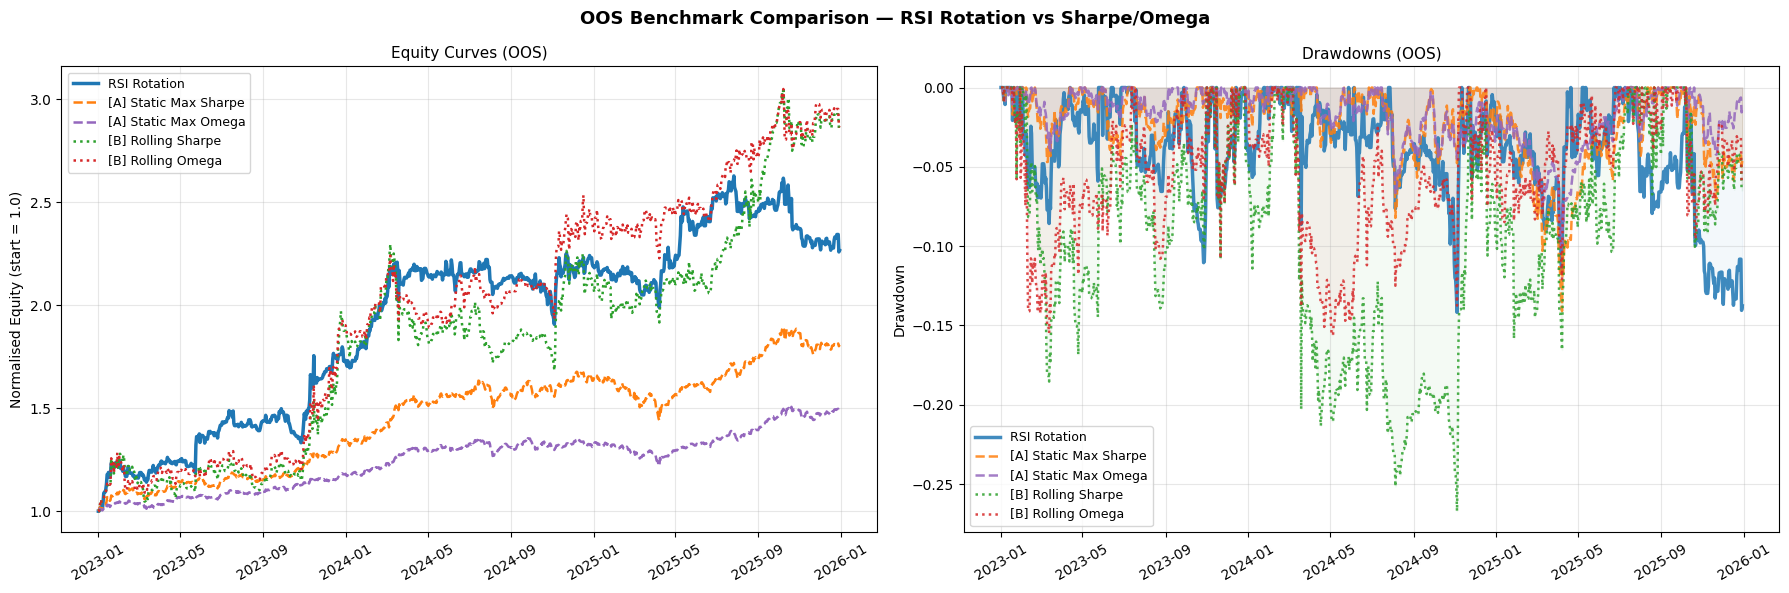

In [25]:
# Cell 10 — Benchmarks: Static Optimised (A) + Dynamic Rolling (B)
#
# FIX 4: run_benchmark_with_costs is NO LONGER redefined here.
#         The single canonical version lives in Cell 9.
#
# FIX 5: all full_metrics() calls pass adpy=252 explicitly.
#         Sharpe is now reported on a 252-trading-day basis throughout,
#         consistent with equity industry convention.
#
# ══════════════════════════════════════════════════════════════════════════════
#  APPROACH A — Static IS-fitted weights (classic walk-forward benchmark)
#  APPROACH B — Dynamic rolling selection (apples-to-apples vs RSI rotation)
# ══════════════════════════════════════════════════════════════════════════════

from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

ROLLING_WINDOW = 60


# ─────────────────────────────────────────────────────────────────────────────
#  APPROACH A helpers
# ─────────────────────────────────────────────────────────────────────────────

def max_sharpe_portfolio(ret_df, rf=0.04):
    years = (ret_df.index[-1] - ret_df.index[0]).days / 365.25
    adpy  = len(ret_df) / years if years > 0 else 252
    mu    = ret_df.mean() * adpy
    sigma = ret_df.cov()  * adpy
    n     = len(mu)
    def neg_sharpe(w):
        port_vol = np.sqrt(w @ sigma @ w)
        return -(w @ mu - rf) / port_vol if port_vol > 0 else 0
    result = minimize(neg_sharpe, np.ones(n)/n, method='SLSQP',
                      bounds=[(0,1)]*n,
                      constraints=[{'type':'eq','fun':lambda w: w.sum()-1}],
                      options={'maxiter':1000,'ftol':1e-12})
    w = pd.Series(result.x, index=ret_df.columns).clip(lower=0)
    return w / w.sum()


def max_omega_portfolio(ret_df, threshold=0.0):
    n = ret_df.shape[1]
    def neg_omega(w):
        r      = ret_df.values @ w
        gains  = r[r > threshold] - threshold
        losses = threshold - r[r <= threshold]
        return -(gains.sum() / losses.sum()) if losses.sum() > 0 else -1e9
    rng = np.random.default_rng(42)
    best_result, best_val = None, np.inf
    for _ in range(10):
        w0     = rng.dirichlet(np.ones(n))
        result = minimize(neg_omega, w0, method='SLSQP',
                          bounds=[(0,1)]*n,
                          constraints=[{'type':'eq','fun':lambda w: w.sum()-1}],
                          options={'maxiter':1000,'ftol':1e-12})
        if result.fun < best_val:
            best_val, best_result = result.fun, result
    w = pd.Series(best_result.x, index=ret_df.columns).clip(lower=0)
    return w / w.sum()


# ─────────────────────────────────────────────────────────────────────────────
#  APPROACH B helpers
# ─────────────────────────────────────────────────────────────────────────────

def rolling_sharpe(ret_series, window, rf_daily=0.04/252):
    """Trailing Sharpe on a 252-day basis for a single asset return series."""
    # FIX 5: rf_daily now uses /252 to match the 252-day annualisation basis.
    mu  = ret_series.rolling(window).mean() - rf_daily
    vol = ret_series.rolling(window).std()
    return (mu / vol.replace(0, np.nan)) * np.sqrt(252)          # <-- 252


def rolling_omega(ret_series, window, threshold=0.0):
    def _omega(x):
        gains  = x[x > threshold] - threshold
        losses = threshold - x[x <= threshold]
        return gains.sum() / losses.sum() if losses.sum() > 0 else np.nan
    return ret_series.rolling(window).apply(_omega, raw=True)


def build_dynamic_weights(score_df, all_positions, all_closes,
                           top_n, safe_haven, rebalance_freq, common_idx):
    pos_df = pd.DataFrame({
        t: all_positions[t].reindex(common_idx, fill_value=0)
        for t in score_df.columns if t in all_positions
    }).reindex(columns=score_df.columns, fill_value=0)

    rebalance_dates = set(
        pd.date_range(common_idx[0], common_idx[-1], freq=rebalance_freq)
        .map(lambda d: common_idx[common_idx <= d].max()
             if len(common_idx[common_idx <= d]) > 0 else pd.NaT)
    )
    rebalance_dates.discard(pd.NaT)
    rebalance_dates.add(common_idx[0])

    risk_universe   = [t for t in score_df.columns if t != safe_haven]
    weight_per_slot = 1.0 / top_n
    weights_out     = pd.DataFrame(0.0, index=common_idx, columns=score_df.columns)
    current_w       = pd.Series(0.0, index=score_df.columns)

    for date in common_idx:
        if date in rebalance_dates:
            scores_today = score_df.loc[date]
            pos_today    = pos_df.loc[date]
            new_w        = pd.Series(0.0, index=score_df.columns)

            eligible = (
                scores_today
                .reindex(risk_universe)
                .dropna()
                [pos_today.reindex(risk_universe).fillna(0) == 1]
                .sort_values(ascending=False)
                .head(top_n)
            )

            slots_filled = 0
            for asset in eligible.index:
                new_w[asset]  = weight_per_slot
                slots_filled += 1

            remaining = top_n - slots_filled
            if remaining > 0 and safe_haven in pos_df.columns:
                if pos_today.get(safe_haven, 0) == 1:
                    new_w[safe_haven] = remaining * weight_per_slot

            current_w = new_w

        weights_out.loc[date] = current_w

    assert weights_out.sum(axis=1).max() <= 1.0 + 1e-9
    return weights_out


# ═════════════════════════════════════════════════════════════════════════════
#  FIT & SIMULATE — APPROACH A (Static)
# ═════════════════════════════════════════════════════════════════════════════

is_ret_df = ret_df[is_mask].copy()
is_ret_df = is_ret_df.loc[:, (is_ret_df.abs() > 1e-10).any(axis=0)]
oos_index = net_ret_oos.index

print('Optimising Max Sharpe...')
w_sharpe = max_sharpe_portfolio(is_ret_df)

print('Optimising Max Omega...')
w_omega  = max_omega_portfolio(is_ret_df)


def static_weights_to_df(w_series, oos_index, rebalance_freq):
    rebalance_dates = set(
        pd.date_range(oos_index[0], oos_index[-1], freq=rebalance_freq)
        .map(lambda d: oos_index[oos_index <= d].max()
             if len(oos_index[oos_index <= d]) > 0 else pd.NaT)
    )
    rebalance_dates.discard(pd.NaT)
    rebalance_dates.add(oos_index[0])

    weights_out = pd.DataFrame(0.0, index=oos_index, columns=w_series.index)
    current_w   = pd.Series(0.0, index=w_series.index)

    for date in oos_index:
        if date in rebalance_dates:
            current_w = w_series.copy()
        weights_out.loc[date] = current_w

    return weights_out


w_A_sharpe_df = static_weights_to_df(w_sharpe, oos_index, REBALANCE_FREQ)
w_A_omega_df  = static_weights_to_df(w_omega,  oos_index, REBALANCE_FREQ)

ret_A_sharpe, _, _, _ = build_portfolio_returns(
    w_A_sharpe_df, all_closes, CRYPTO_TICKERS, TQQQ_DECAY_BPS_PER_DAY
)
ret_A_omega, _, _, _ = build_portfolio_returns(
    w_A_omega_df, all_closes, CRYPTO_TICKERS, TQQQ_DECAY_BPS_PER_DAY
)

eq_A_sharpe = (1 + ret_A_sharpe).cumprod()
eq_A_omega  = (1 + ret_A_omega).cumprod()

print(f'\n  Sharpe BM equity: {eq_A_sharpe.iloc[0]:.3f} → {eq_A_sharpe.iloc[-1]:.3f}')
print(f'  Omega  BM equity: {eq_A_omega.iloc[0]:.3f}  → {eq_A_omega.iloc[-1]:.3f}')

print('\n  Max Sharpe weights (IS-fitted):')
display(w_sharpe[w_sharpe > 0.01].sort_values(ascending=False).map('{:.1%}'.format))
print('\n  Max Omega weights (IS-fitted):')
display(w_omega[w_omega > 0.01].sort_values(ascending=False).map('{:.1%}'.format))


# ═════════════════════════════════════════════════════════════════════════════
#  FIT & SIMULATE — APPROACH B (Dynamic rolling)
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '═'*60)
print(f'APPROACH B — Dynamic rolling top-{TOP_N} selection')
print(f'  Look-back window : {ROLLING_WINDOW} days')
print(f'  Rebalance        : {REBALANCE_FREQ}')
print(f'  Sharpe basis     : 252 trading days')
print('═'*60)

full_ret_df = pd.DataFrame({
    t: all_closes[t].reindex(FULL_INDEX).pct_change().fillna(0)
    for t in is_ret_df.columns if t in all_closes
})

sharpe_scores = pd.DataFrame({
    t: rolling_sharpe(full_ret_df[t], ROLLING_WINDOW).shift(1)
    for t in full_ret_df.columns
})

omega_scores = pd.DataFrame({
    t: rolling_omega(full_ret_df[t], ROLLING_WINDOW).shift(1)
    for t in full_ret_df.columns
})

sharpe_scores_oos = sharpe_scores.reindex(oos_index)
omega_scores_oos  = omega_scores.reindex(oos_index)

print('  Building dynamic Sharpe weights...')
w_B_sharpe_df = build_dynamic_weights(
    sharpe_scores_oos, all_positions, all_closes,
    TOP_N, SAFE_HAVEN, REBALANCE_FREQ, oos_index
)

print('  Building dynamic Omega weights...')
w_B_omega_df = build_dynamic_weights(
    omega_scores_oos, all_positions, all_closes,
    TOP_N, SAFE_HAVEN, REBALANCE_FREQ, oos_index
)

ret_B_sharpe, _, _, _ = build_portfolio_returns(
    w_B_sharpe_df, all_closes, CRYPTO_TICKERS, TQQQ_DECAY_BPS_PER_DAY
)
ret_B_omega, _, _, _ = build_portfolio_returns(
    w_B_omega_df, all_closes, CRYPTO_TICKERS, TQQQ_DECAY_BPS_PER_DAY
)

eq_B_sharpe = (1 + ret_B_sharpe).cumprod()
eq_B_omega  = (1 + ret_B_omega).cumprod()

print(f'\n  Rolling Sharpe equity: {eq_B_sharpe.iloc[0]:.3f} → {eq_B_sharpe.iloc[-1]:.3f}')
print(f'  Rolling Omega  equity: {eq_B_omega.iloc[0]:.3f}  → {eq_B_omega.iloc[-1]:.3f}')


# ═════════════════════════════════════════════════════════════════════════════
#  METRICS TABLE — FIX 5: all calls pass adpy=252 explicitly
#  Sharpe_basis column confirms the convention used
# ═════════════════════════════════════════════════════════════════════════════

m_rotation = full_metrics(net_ret_oos,  equity_oos,  label='RSI Rotation (OOS)',        adpy=252)
m_A_sharpe = full_metrics(ret_A_sharpe, eq_A_sharpe, label='[A] Static Max Sharpe',     adpy=252)
m_A_omega  = full_metrics(ret_A_omega,  eq_A_omega,  label='[A] Static Max Omega',      adpy=252)
m_B_sharpe = full_metrics(ret_B_sharpe, eq_B_sharpe, label='[B] Rolling Sharpe Top-N', adpy=252)
m_B_omega  = full_metrics(ret_B_omega,  eq_B_omega,  label='[B] Rolling Omega Top-N',  adpy=252)

results_df = pd.DataFrame([m_rotation, m_A_sharpe, m_A_omega, m_B_sharpe, m_B_omega])

print('\n')
print('═'*60)
print('BENCHMARK COMPARISON — OOS (Sharpe on 252-day basis)')
print()
print('  APPROACH A: weights fit once on IS data, held & rebalanced OOS')
print('  APPROACH B: top-N picked dynamically each Friday by rolling score')
print('═'*60)
display(results_df.set_index('Label')[['CAGR','Sharpe','MaxDD','Calmar','WinRate','Years','Sharpe_basis']])


# ═════════════════════════════════════════════════════════════════════════════
#  PLOT — OOS equity curves (unchanged from original)
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
fig.suptitle('OOS Benchmark Comparison — RSI Rotation vs Sharpe/Omega',
             fontsize=13, fontweight='bold')

styles = [
    (equity_oos,  net_ret_oos,  'RSI Rotation',          '#1f77b4', '-',  2.5),
    (eq_A_sharpe, ret_A_sharpe, '[A] Static Max Sharpe', '#ff7f0e', '--', 1.8),
    (eq_A_omega,  ret_A_omega,  '[A] Static Max Omega',  '#9467bd', '--', 1.8),
    (eq_B_sharpe, ret_B_sharpe, '[B] Rolling Sharpe',    '#2ca02c', ':',  1.8),
    (eq_B_omega,  ret_B_omega,  '[B] Rolling Omega',     '#d62728', ':',  1.8),
]

ax = axes[0]
for eq, _, label, color, ls, lw in styles:
    eq_n = eq / eq.iloc[0]
    ax.plot(eq_n.index, eq_n.values, label=label, color=color,
            linestyle=ls, linewidth=lw)
ax.set_title('Equity Curves (OOS)', fontsize=11)
ax.set_ylabel('Normalised Equity (start = 1.0)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
for eq, _, label, color, ls, lw in styles:
    eq_n = eq / eq.iloc[0]
    dd   = eq_n / eq_n.cummax() - 1
    ax.plot(dd.index, dd.values, label=label, color=color,
            linestyle=ls, linewidth=lw, alpha=0.85)
    ax.fill_between(dd.index, dd.values, 0, color=color, alpha=0.05)
ax.set_title('Drawdowns (OOS)', fontsize=11)
ax.set_ylabel('Drawdown')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

═══ Asset Correlation Matrix (IS, merged calendar) ═══



,SMH,GDX,DGRW,DXJ,BOTZ,LIT,URNM,ARKK,ARKG,HACK,...,XLB,XLP,XLY,VNQ,XLRE,TLT,HYG,EFA,VGK,^NSEI
SMH,1.0000,0.2000,0.7900,0.6700,0.8500,0.6900,0.5100,0.7600,0.6800,0.7600,...,0.7100,0.5300,0.8100,0.5700,0.5500,-0.1700,0.6500,0.7600,0.7400,0.2000
GDX,0.2000,1.0000,0.1900,0.0700,0.2200,0.2500,0.3500,0.2100,0.2200,0.2300,...,0.3100,0.1900,0.2000,0.2100,0.2000,0.2000,0.2500,0.2900,0.3000,0.0200
DGRW,0.7900,0.1900,1.0000,0.7800,0.8100,0.6500,0.4600,0.6200,0.5800,0.7400,...,0.8800,0.8400,0.8500,0.7900,0.7700,-0.2700,0.7700,0.8600,0.8400,0.2900
DXJ,0.6700,0.0700,0.7800,1.0000,0.7800,0.6000,0.4300,0.5100,0.4800,0.6000,...,0.7400,0.5900,0.7000,0.6000,0.5700,-0.3600,0.5900,0.8300,0.7700,0.3100
BOTZ,0.8500,0.2200,0.8100,0.7800,1.0000,0.7400,0.5600,0.7800,0.7200,0.8100,...,0.7800,0.5800,0.8500,0.6500,0.6200,-0.1800,0.7200,0.8700,0.8300,0.3000
LIT,0.6900,0.2500,0.6500,0.6000,0.7400,1.0000,0.5000,0.6600,0.5900,0.6200,...,0.6900,0.4400,0.6900,0.5300,0.5000,-0.2000,0.5900,0.7100,0.6900,0.3100
URNM,0.5100,0.3500,0.4600,0.4300,0.5600,0.5000,1.0000,0.4900,0.4800,0.5100,...,0.5100,0.3500,0.5000,0.4200,0.4100,-0.1600,0.4100,0.5400,0.5300,0.2500
ARKK,0.7600,0.2100,0.6200,0.5100,0.7800,0.6600,0.4900,1.0000,0.9200,0.8200,...,0.5700,0.3700,0.8000,0.5100,0.4900,-0.0600,0.6200,0.6500,0.6300,0.1900
ARKG,0.6800,0.2200,0.5800,0.4800,0.7200,0.5900,0.4800,0.9200,1.0000,0.7600,...,0.5300,0.3600,0.7000,0.4700,0.4500,-0.0400,0.5700,0.6000,0.5800,0.1800
HACK,0.7600,0.2300,0.7400,0.6000,0.8100,0.6200,0.5100,0.8200,0.7600,1.0000,...,0.6500,0.5200,0.8000,0.6100,0.5900,-0.0900,0.6600,0.7100,0.6900,0.2400


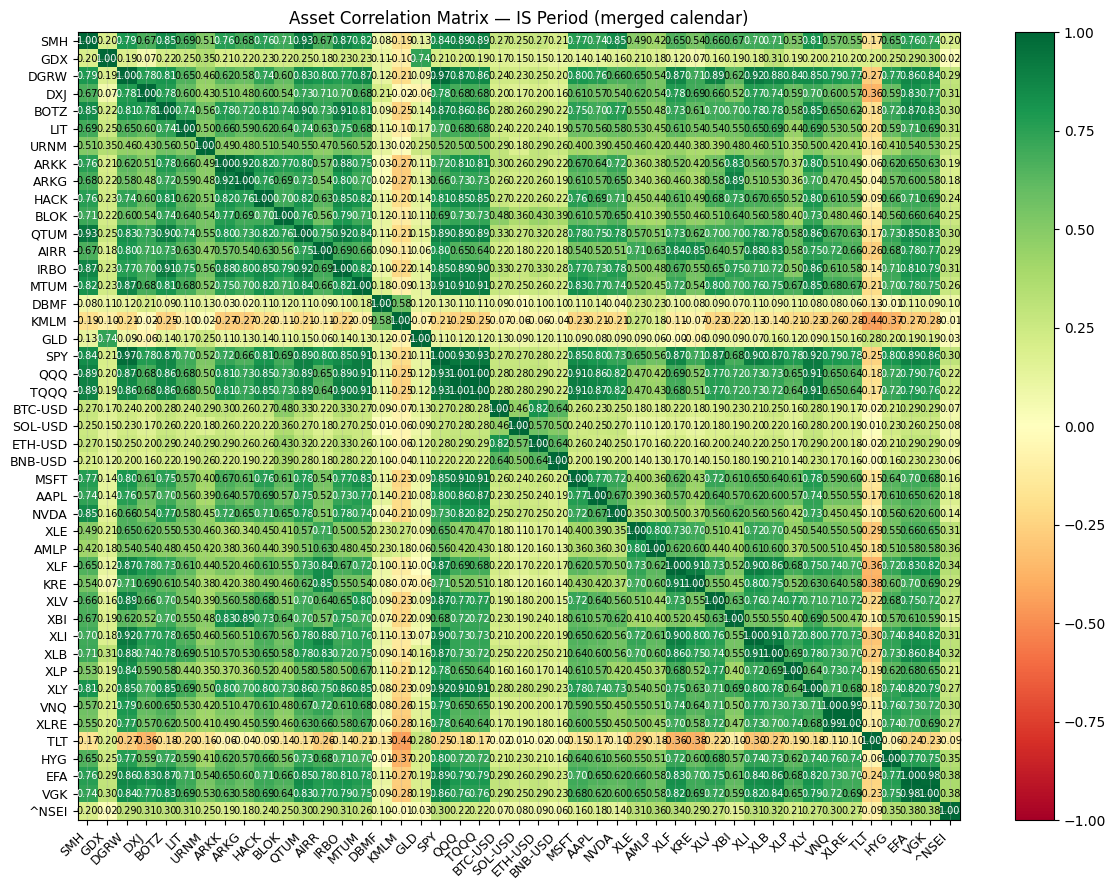

In [26]:
# Cell 11 — Correlation Matrix
# OPTION C CHANGE:
# Removed equity_day_mask_corr. The merged calendar handles it correctly:
# equity weekend pct_change = 0, crypto = real. This slightly deflates
# equity annualised vol vs a pure 252-day series, but is the correct
# representation for the mixed-calendar universe.

print('═══ Asset Correlation Matrix (IS, merged calendar) ═══\n')

bnh_rets = pd.DataFrame({
    t: all_closes[t].reindex(FULL_INDEX).pct_change()
    for t in TICKERS if t in all_closes
})[is_mask]

corr = bnh_rets.corr().round(2)
display(corr)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='black' if abs(corr.iloc[i, j]) < 0.7 else 'white')
ax.set_title('Asset Correlation Matrix — IS Period (merged calendar)', fontsize=12)
plt.tight_layout()
plt.show()

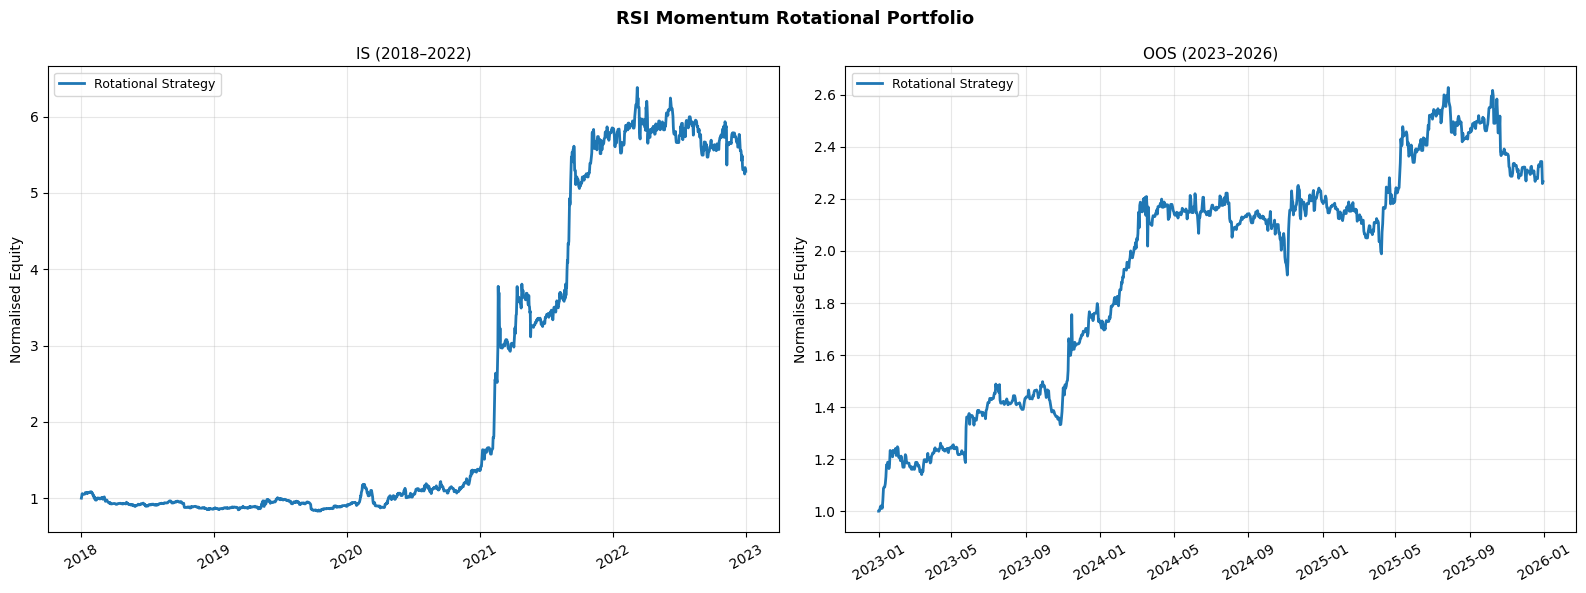

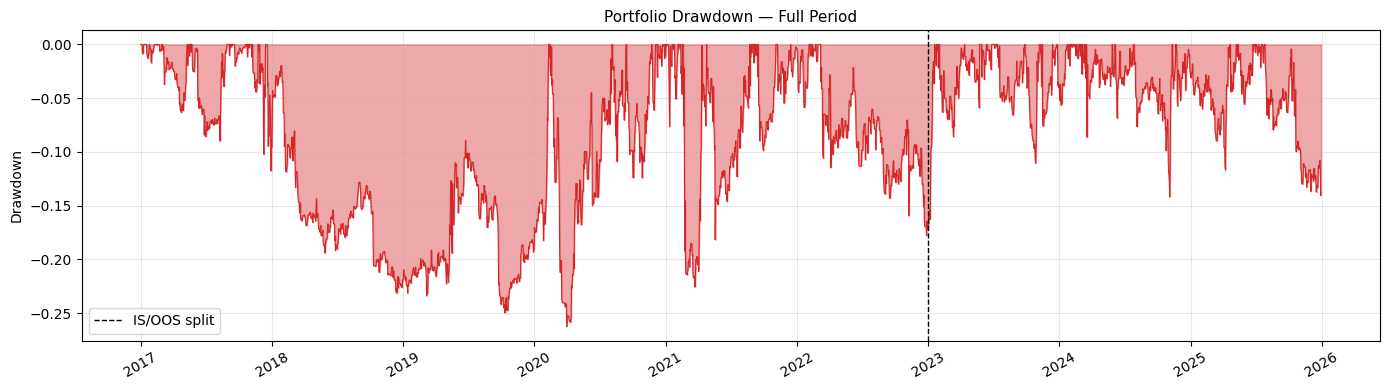

In [27]:
# Cell 12 — Equity Curve & Drawdown Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RSI Momentum Rotational Portfolio', fontsize=13, fontweight='bold')

for ax, (phase, mask, net_r, eq) in zip(axes, [
    ('IS (2018–2022)',   is_mask,  net_ret_is,  equity_is),
    ('OOS (2023–2026)', oos_mask, net_ret_oos, equity_oos),
]):
    eq_n = eq / eq.iloc[0]
    ax.plot(eq_n.index, eq_n.values, color='#1f77b4',
            linewidth=2.0, label='Rotational Strategy')

    bh_colors = plt.cm.tab10(np.linspace(0, 1, len(TICKERS)))
    for i, t in enumerate(TICKERS):
        if t not in all_closes:
            continue
        cl   = all_closes[t].reindex(eq.index)
        bh   = (1 + cl.pct_change()).cumprod()
        bh_n = bh / bh.iloc[0]
        ax.plot(bh_n.index, bh_n.values,
                color=bh_colors[i], linewidth=0.7,
                alpha=0.35, linestyle='--', label=t)

    ax.set_title(phase, fontsize=11)
    ax.set_ylabel('Normalised Equity')
    ax.tick_params(axis='x', rotation=30)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1], labels[:1], fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
dd = (equity_full - equity_full.cummax()) / equity_full.cummax()
ax.fill_between(dd.index, dd.values, 0, color='#d62728', alpha=0.4)
ax.plot(dd.index, dd.values, color='#d62728', linewidth=0.8)
ax.axvline(pd.Timestamp(OOS_START), color='black', linestyle='--',
           linewidth=1.0, label='IS/OOS split')
ax.set_title('Portfolio Drawdown — Full Period', fontsize=11)
ax.set_ylabel('Drawdown')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

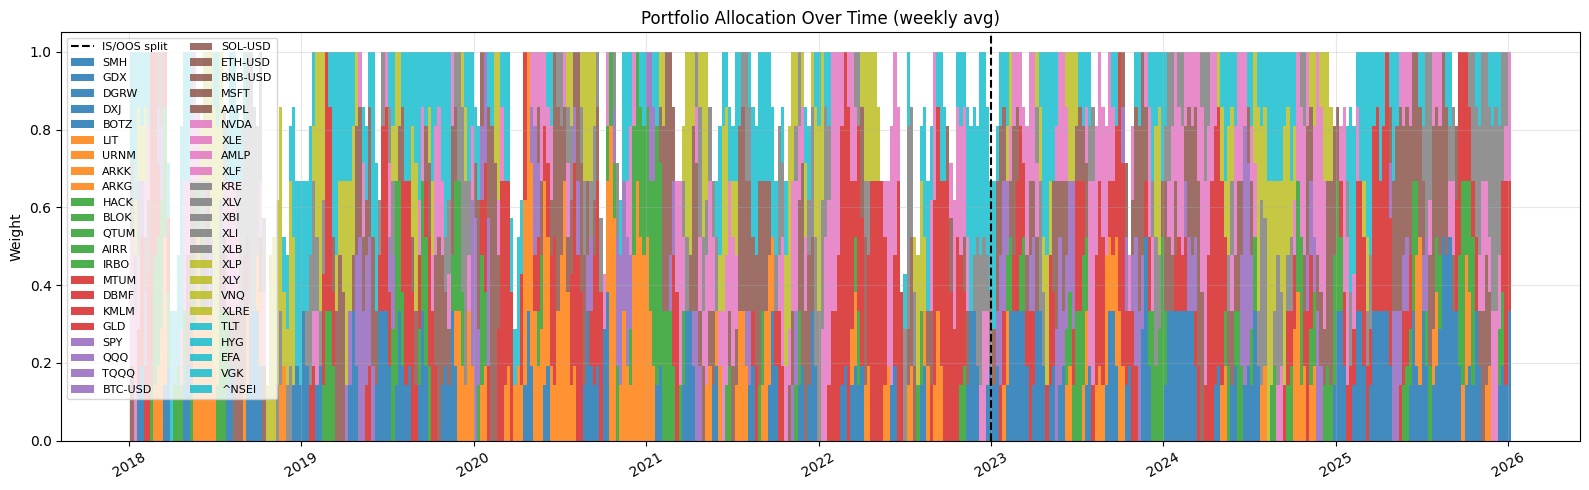


═══ Average Allocation by Asset ═══


GLD        6.9%
^NSEI      4.7%
AAPL       4.6%
NVDA       3.7%
BTC-USD    3.1%
XLE        3.0%
XLV        2.9%
DBMF       2.9%
GDX        2.9%
DXJ        2.8%
MSFT       2.8%
XLRE       2.6%
TLT        2.5%
AMLP       2.5%
XLY        2.3%
LIT        2.1%
URNM       2.1%
XLP        2.0%
KMLM       2.0%
HACK       1.8%
HYG        1.8%
VNQ        1.7%
ARKK       1.7%
ETH-USD    1.7%
ARKG       1.6%
SOL-USD    1.5%
BNB-USD    1.5%
BOTZ       1.5%
MTUM       1.4%
DGRW       1.4%
XLI        1.4%
SMH        1.4%
KRE        1.3%
BLOK       1.3%
XLF        1.3%
XBI        1.3%
EFA        1.2%
VGK        1.2%
IRBO       1.1%
AIRR       1.1%
QQQ        1.1%
QTUM       0.9%
SPY        0.8%
TQQQ       0.7%
XLB        0.7%
Name: Avg Weight, dtype: object


═══ Cash Allocation ═══
  Days in partial/full cash: 15.7%


In [28]:
# Cell 13 — Allocation Stacked Bar Chart
fig, ax = plt.subplots(figsize=(16, 5))

w_weekly = weights_df.resample('W').mean()
w_weekly = w_weekly.loc[w_weekly.index >= IS_START]

colors = plt.cm.tab10(np.linspace(0, 1, len(weights_df.columns)))
bottom = np.zeros(len(w_weekly))

for i, col in enumerate(weights_df.columns):
    vals = w_weekly[col].fillna(0).values
    ax.bar(w_weekly.index, vals, bottom=bottom,
           color=colors[i], label=col, width=7, alpha=0.85)
    bottom += vals

ax.axvline(pd.Timestamp(OOS_START), color='black', linestyle='--',
           linewidth=1.5, label='IS/OOS split')
ax.set_title('Portfolio Allocation Over Time (weekly avg)', fontsize=12)
ax.set_ylabel('Weight')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('\n═══ Average Allocation by Asset ═══')
avg_alloc = weights_df.mean().sort_values(ascending=False)
display(avg_alloc.map('{:.1%}'.format).rename('Avg Weight'))

print(f'\n═══ Cash Allocation ═══')
cash_pct = (weights_df.sum(axis=1) < 0.999).mean()
print(f'  Days in partial/full cash: {cash_pct:.1%}')

Building correlation-filtered portfolio weights...
Weight sum stats:
  Mean : 0.960
  Min  : 0.000
  Max  : 1.000
  % days fully invested : 91.5%
  % days in cash        : 0.8%

Rebalance events       : 457
Avg turnover per event : 126.0%

Correlation-filtered weights built ✓
═══ Original vs Correlation-Filtered (Sharpe: 252-day basis) ═══



,CAGR,Sharpe,MaxDD,Calmar,WinRate
Label,,,,,
Original (IS),0.3955,1.0120,-0.2623,1.5079,0.3872
Original (OOS),0.3141,1.0560,-0.1417,2.2166,0.3927
Corr-Filtered (IS),0.4100,1.0221,-0.3419,1.1993,0.3927
Corr-Filtered (OOS),0.3541,1.1551,-0.1791,1.9772,0.3890


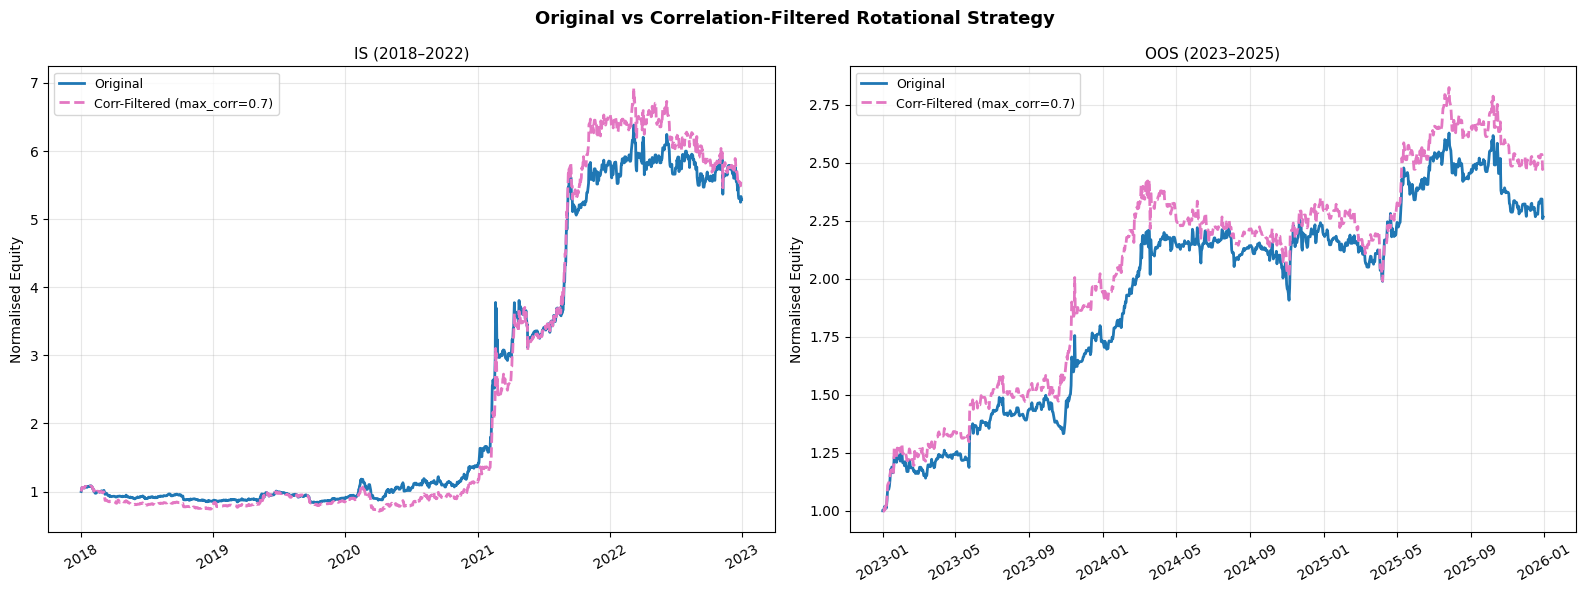

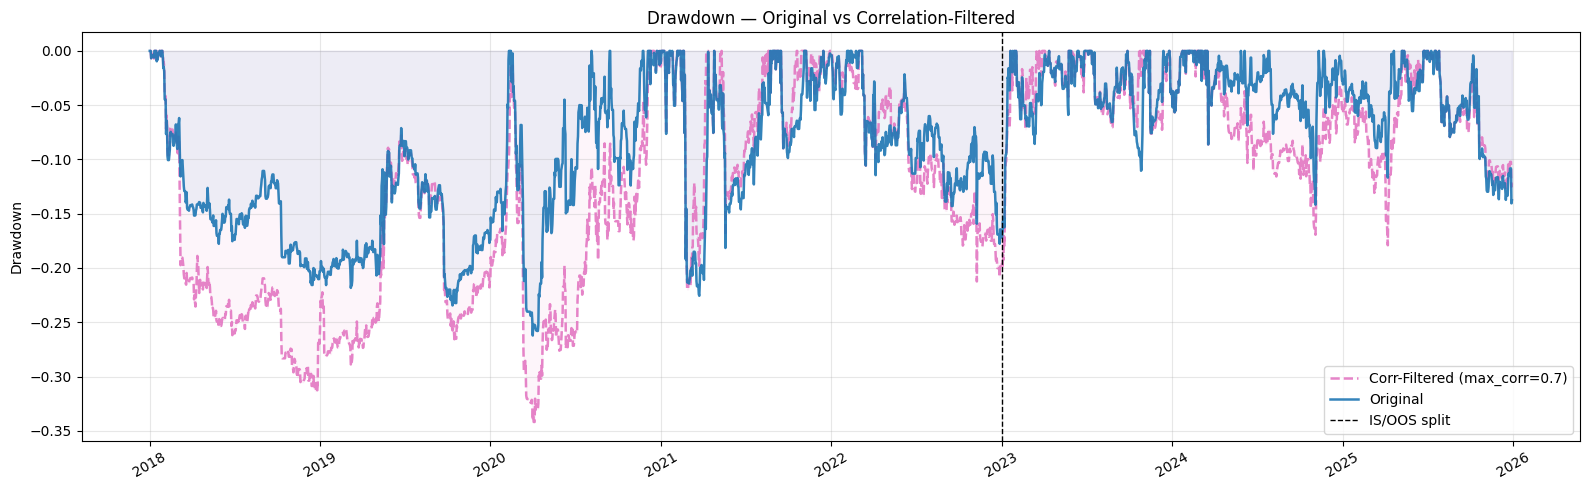

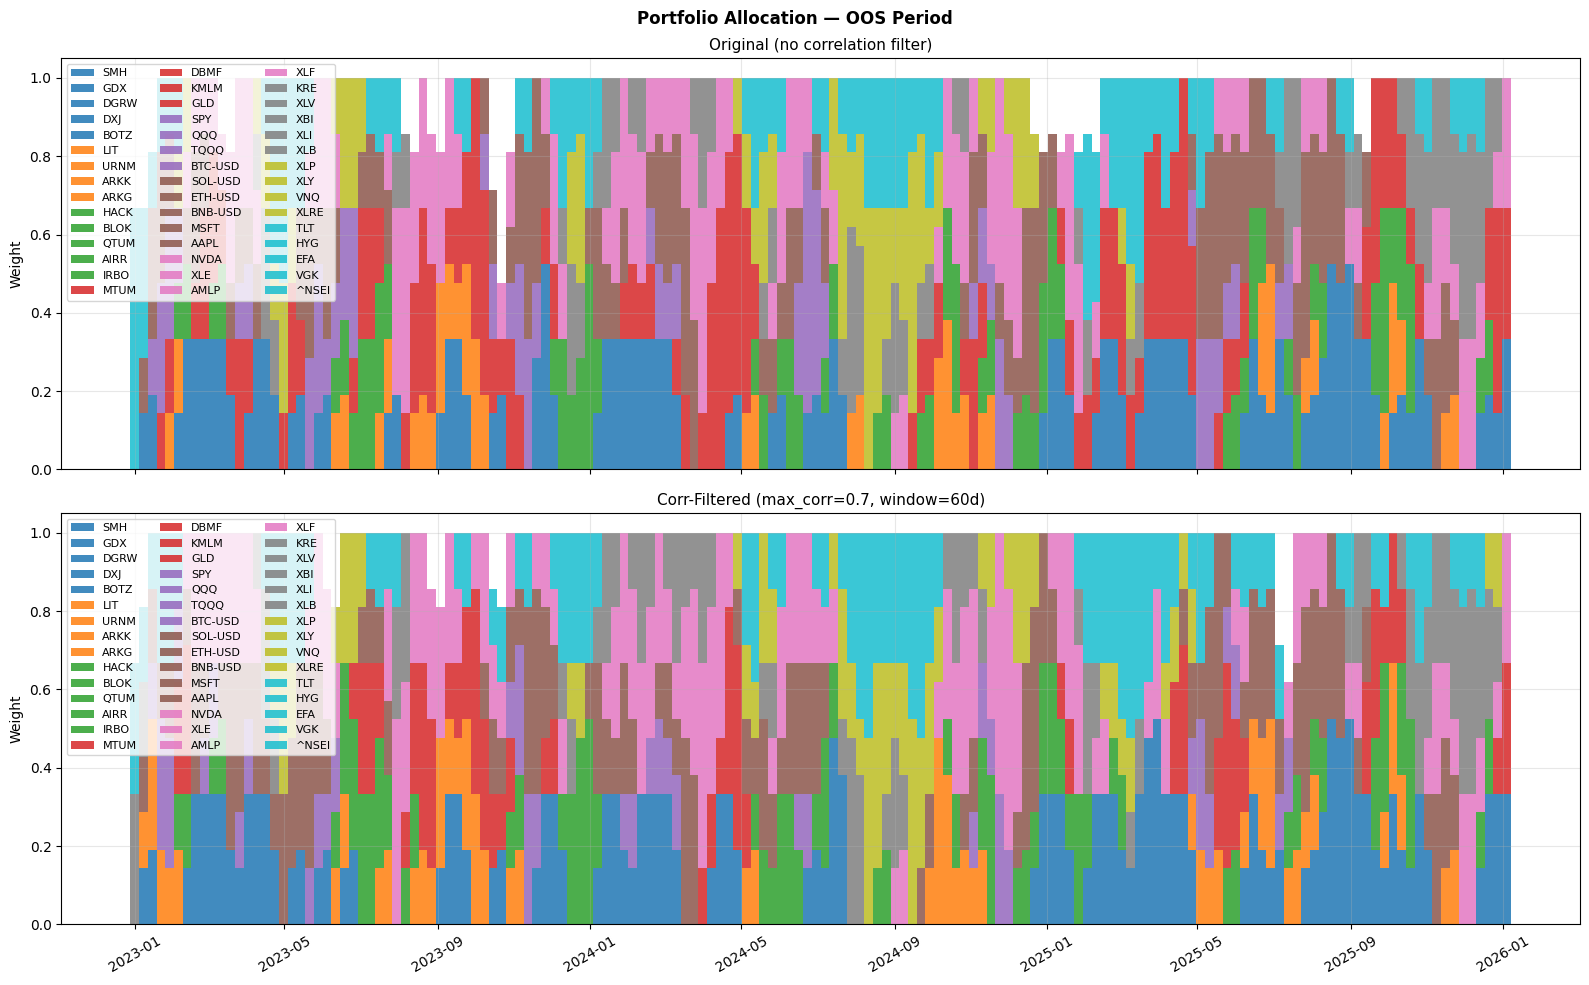

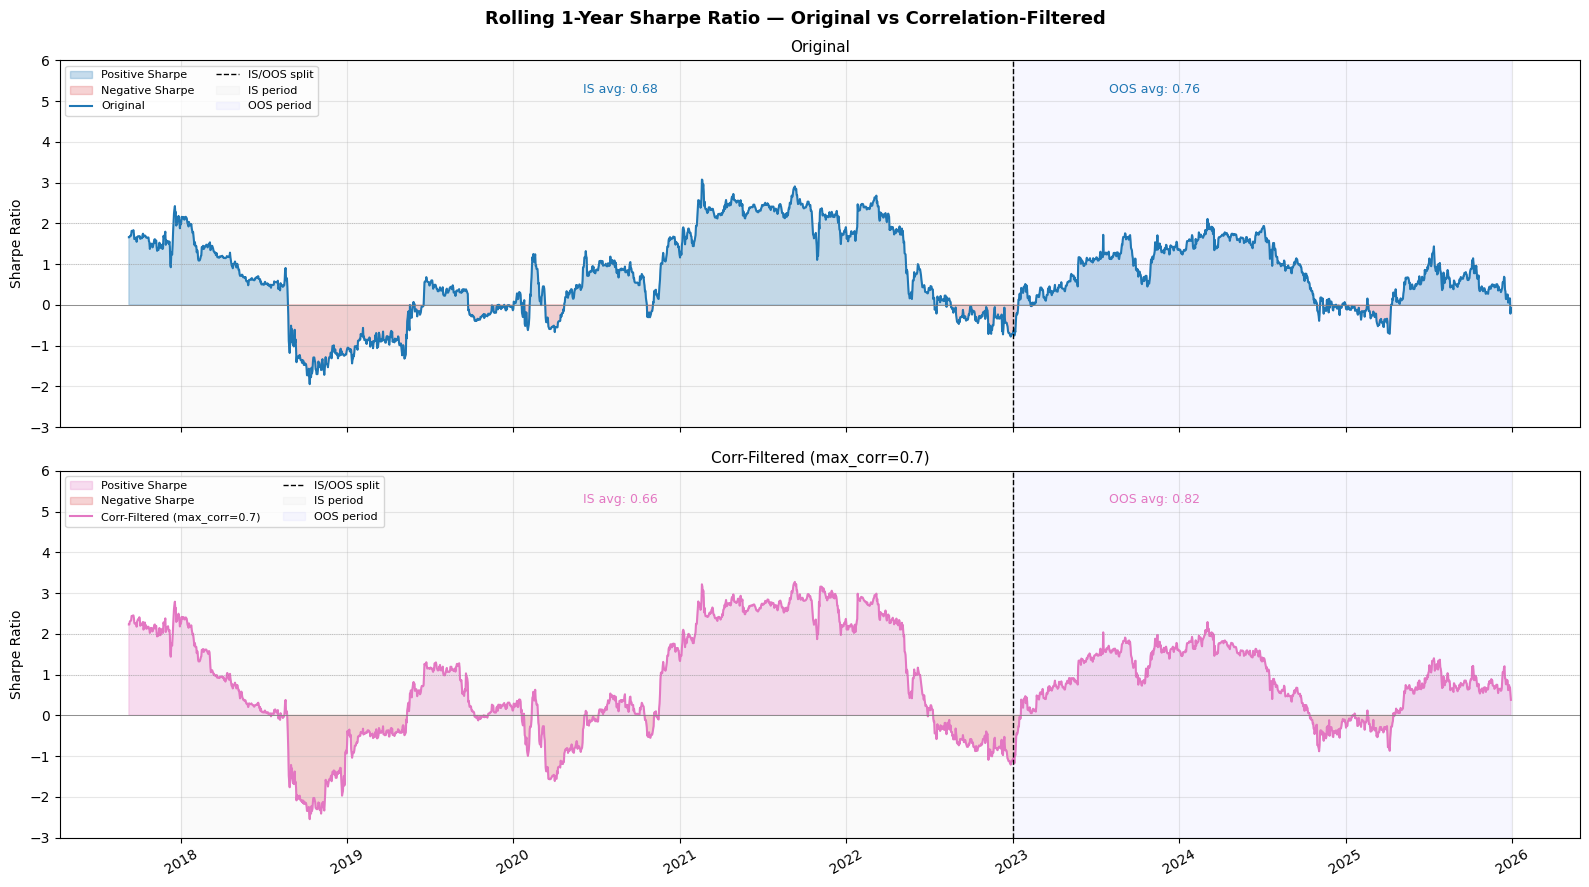

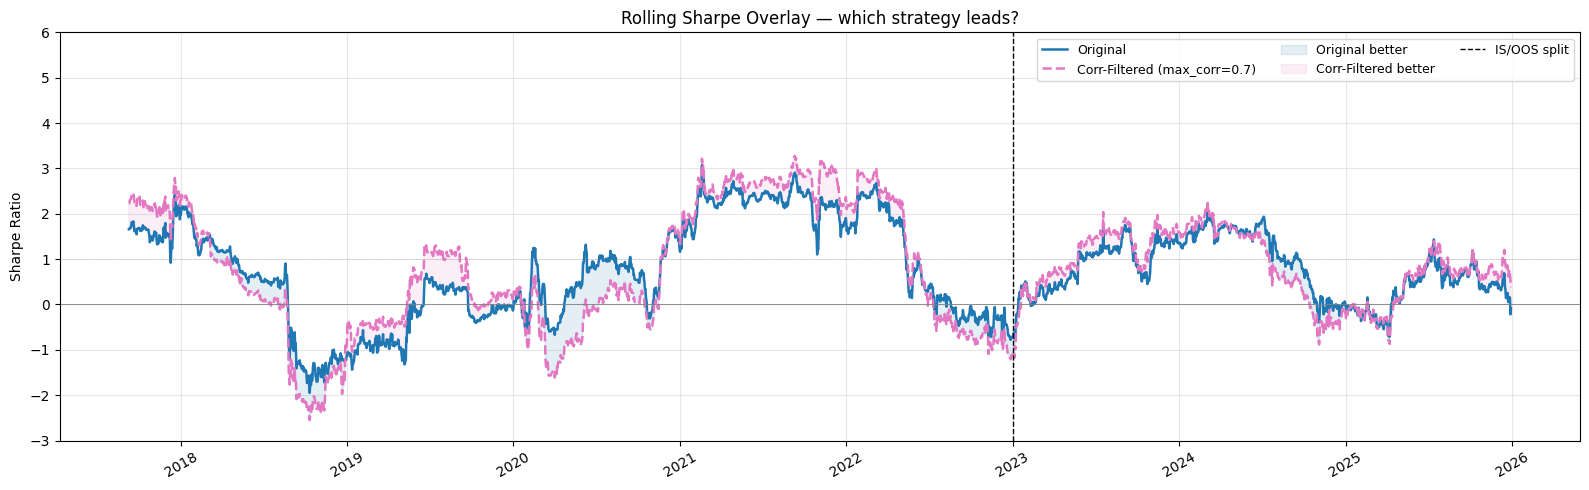


═══ Rolling Sharpe Summary ═══



,IS mean,IS min,IS max,OOS mean,OOS min,OOS max,% time > 1,% time < 0
Original,0.6770,-1.9480,3.0730,0.7610,-0.7540,2.1070,0.3750,0.2330
Corr-Filtered,0.6620,-2.5490,3.2740,0.8150,-1.1770,2.2890,0.3820,0.2590



═══ Full Comparison vs SPY Buy & Hold (Sharpe: 252-day basis) ═══



,CAGR,Sharpe,MaxDD,Calmar,WinRate,Years
Label,,,,,,
Original (IS),0.3955,1.0120,-0.2623,1.5079,0.3872,5.0000
Original (OOS),0.3141,1.0560,-0.1417,2.2166,0.3927,3.0000
Corr-Filtered (IS),0.4100,1.0221,-0.3419,1.1993,0.3927,5.0000
Corr-Filtered (OOS),0.3541,1.1551,-0.1791,1.9772,0.3890,3.0000
SPY BnH (IS),0.0932,0.4334,-0.3372,0.2764,0.3746,5.0000
SPY BnH (OOS),0.2322,1.1946,-0.1876,1.2378,0.3936,3.0000


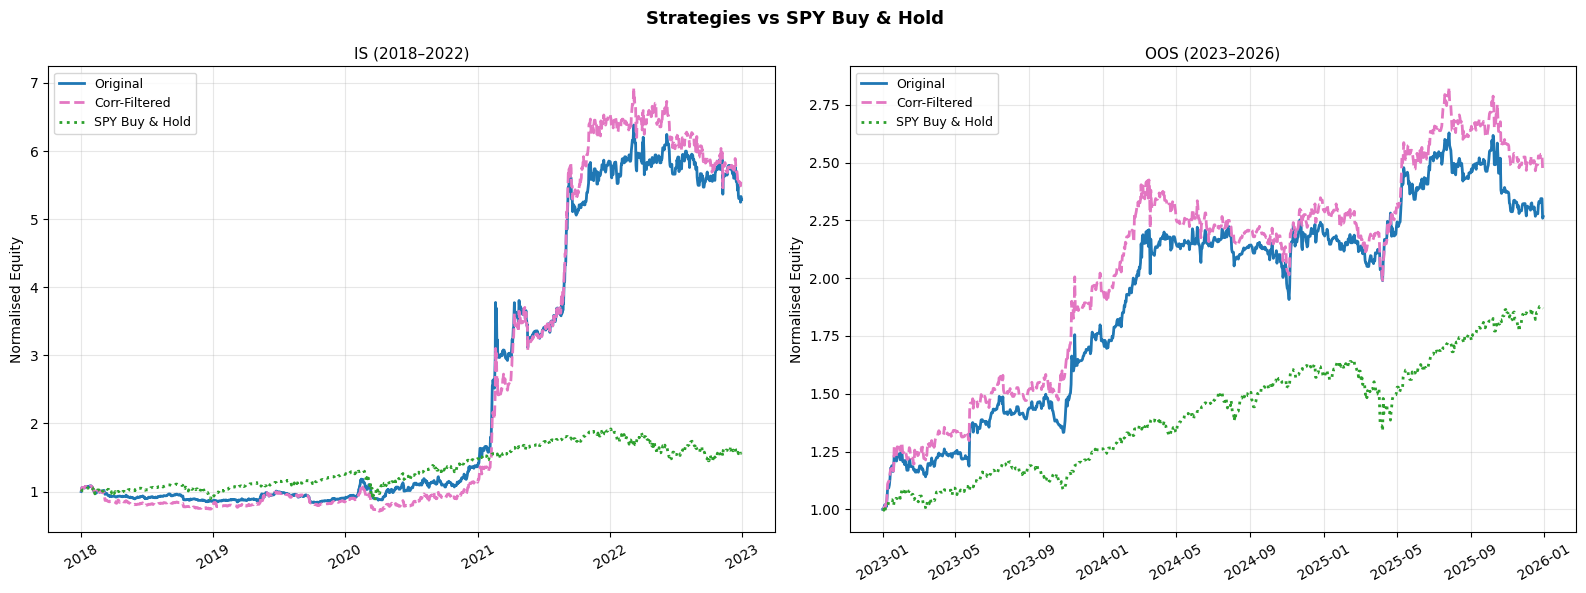

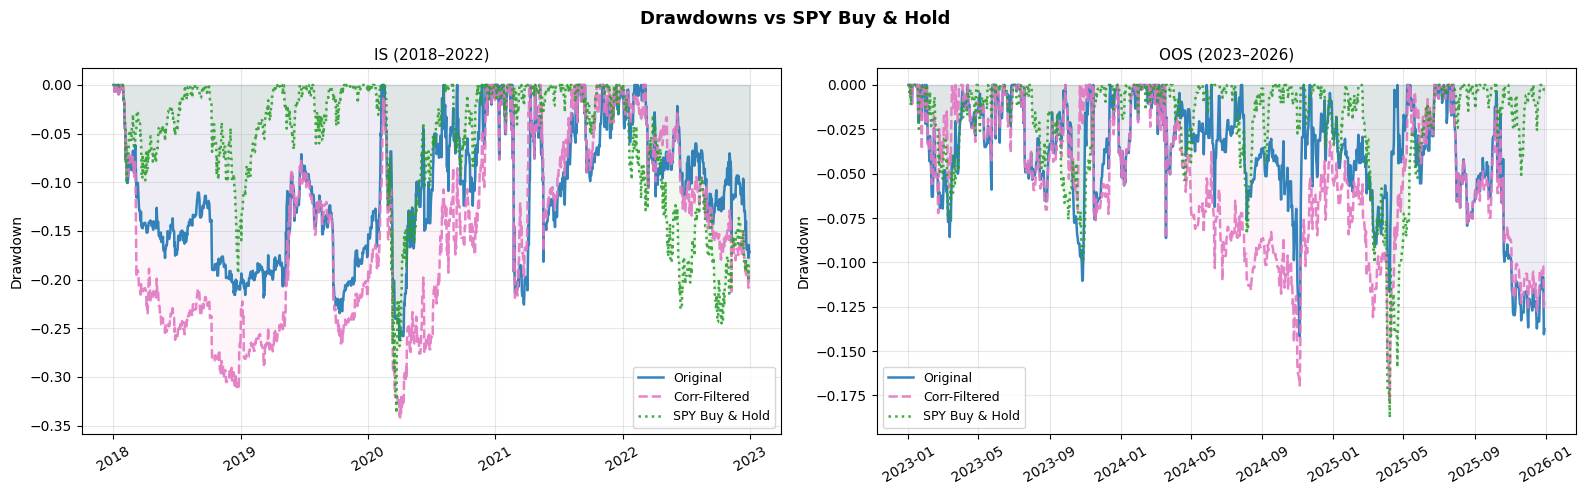

In [29]:

# Cell 14: CORRELATION FILTER
CORR_WINDOW = 60
MAX_CORR    = 0.70

def build_portfolio_weights_corr(rsi_ranks, all_positions, all_closes,
                                  top_n, safe_haven, tickers,
                                  rebalance_freq, max_corr, corr_window):
    common_idx = rsi_ranks.index
    pos_df = pd.DataFrame({
        t: all_positions[t].reindex(common_idx, fill_value=0)
        for t in tickers if t in all_positions
    })
    rank_df = rsi_ranks.reindex(columns=pos_df.columns)

    ret_df_local = pd.DataFrame({
        t: all_closes[t].reindex(common_idx).pct_change().fillna(0)
        for t in pos_df.columns if t in all_closes
    })

    weight_per_slot = 1.0 / top_n
    weights_corr_df = pd.DataFrame(0.0, index=common_idx, columns=pos_df.columns)
    risk_universe   = [t for t in pos_df.columns if t != safe_haven]

    rebalance_dates = set(
        pd.date_range(common_idx[0], common_idx[-1], freq=rebalance_freq)
        .map(lambda d: common_idx[common_idx <= d].max()
             if len(common_idx[common_idx <= d]) > 0 else pd.NaT)
    )
    rebalance_dates.discard(pd.NaT)

    current_weights = pd.Series(0.0, index=pos_df.columns)

    # Convert index to positional for leak-free slicing
    idx_map = {date: i for i, date in enumerate(common_idx)}

    for date in common_idx:
        if date in rebalance_dates:
            ranks_today = rank_df.loc[date]
            pos_today   = pos_df.loc[date]
            new_weights = pd.Series(0.0, index=pos_df.columns)

            # FIX: use strictly past returns — exclude today's row (idx_map[date])
            # so the correlation window contains only returns[0 : idx_map[date]],
            # i.e. everything up to and including yesterday.
            past_idx    = idx_map[date]
            hist        = ret_df_local.iloc[max(0, past_idx - corr_window) : past_idx]
            corr_matrix = hist.corr()

            top_ranked = ranks_today[
                ranks_today.index.isin(risk_universe) &
                (ranks_today <= top_n * 3)
            ].sort_values().index.tolist()

            eligible_risk = [t for t in top_ranked if pos_today.get(t, 0) == 1]

            selected = []
            for candidate in eligible_risk:
                if len(selected) >= top_n:
                    break
                if len(selected) == 0:
                    selected.append(candidate)
                    continue
                corrs = []
                for already_in in selected:
                    try:
                        c = abs(corr_matrix.loc[candidate, already_in])
                    except KeyError:
                        c = 0.0
                    corrs.append(c)
                if max(corrs) < max_corr:
                    selected.append(candidate)

            slots_filled = 0
            for asset in selected:
                new_weights[asset] = weight_per_slot
                slots_filled += 1

            remaining = top_n - slots_filled
            if remaining > 0 and safe_haven in pos_df.columns:
                if pos_today.get(safe_haven, 0) == 1:
                    new_weights[safe_haven] = remaining * weight_per_slot

            current_weights = new_weights

        weights_corr_df.loc[date] = current_weights

    row_sums = weights_corr_df.sum(axis=1)
    assert row_sums.max() <= 1.0 + 1e-9, \
        f'Weight sum exceeded 1.0! Max = {row_sums.max():.6f}'

    return weights_corr_df


print('Building correlation-filtered portfolio weights...')
weights_corr_df = build_portfolio_weights_corr(
    rsi_ranks, all_positions, all_closes,
    TOP_N, SAFE_HAVEN, TICKERS,
    REBALANCE_FREQ, MAX_CORR, CORR_WINDOW
)

net_ret_corr, gross_ret_corr, costs_corr, _ = build_portfolio_returns(
    weights_corr_df, all_closes, CRYPTO_TICKERS, TQQQ_DECAY_BPS_PER_DAY
)

is_mask_c  = (net_ret_corr.index >= IS_START)  & (net_ret_corr.index <= IS_END)
oos_mask_c = (net_ret_corr.index >= OOS_START) & (net_ret_corr.index <= OOS_END)

equity_corr_full = (1 + net_ret_corr).cumprod()
equity_corr_is   = (1 + net_ret_corr[is_mask_c]).cumprod()
equity_corr_oos  = (1 + net_ret_corr[oos_mask_c]).cumprod()

weight_sums_corr = weights_corr_df.sum(axis=1)
print(f'Weight sum stats:')
print(f'  Mean : {weight_sums_corr.mean():.3f}')
print(f'  Min  : {weight_sums_corr.min():.3f}')
print(f'  Max  : {weight_sums_corr.max():.3f}')
print(f'  % days fully invested : {(weight_sums_corr >= 0.999).mean():.1%}')
print(f'  % days in cash        : {(weight_sums_corr < 0.001).mean():.1%}')

turnovers_corr      = weights_corr_df.diff().abs().sum(axis=1)
rebalance_days_corr = turnovers_corr[turnovers_corr > 0.001]
print(f'\nRebalance events       : {len(rebalance_days_corr)}')
print(f'Avg turnover per event : {rebalance_days_corr.mean():.1%}')
print('\nCorrelation-filtered weights built ✓')

orig_is  = full_metrics(net_ret[is_mask],         equity_is,       label='Original (IS)',        adpy=252)
orig_oos = full_metrics(net_ret[oos_mask],         equity_oos,      label='Original (OOS)',       adpy=252)
corr_is  = full_metrics(net_ret_corr[is_mask_c],  equity_corr_is,  label='Corr-Filtered (IS)',   adpy=252)
corr_oos = full_metrics(net_ret_corr[oos_mask_c], equity_corr_oos, label='Corr-Filtered (OOS)',  adpy=252)

comparison_df = pd.DataFrame([orig_is, orig_oos, corr_is, corr_oos])
print('═══ Original vs Correlation-Filtered (Sharpe: 252-day basis) ═══\n')
display(comparison_df.set_index('Label')[['CAGR','Sharpe','MaxDD','Calmar','WinRate']])


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Original vs Correlation-Filtered Rotational Strategy',
             fontsize=13, fontweight='bold')

for ax, (phase, is_m, oos_m) in zip(axes, [
    ('IS (2018–2022)',  is_mask,  is_mask_c),
    ('OOS (2023–2025)', oos_mask, oos_mask_c),
]):
    orig_eq = (1 + net_ret[is_m if 'IS' in phase else oos_m]).cumprod()
    corr_eq = (1 + net_ret_corr[is_m if 'IS' in phase else oos_mask_c]).cumprod()
    orig_n  = orig_eq / orig_eq.iloc[0]
    corr_n  = corr_eq / corr_eq.iloc[0]
    ax.plot(orig_n.index, orig_n.values,
            color='#1f77b4', linewidth=2.0, label='Original')
    ax.plot(corr_n.index, corr_n.values,
            color='#e377c2', linewidth=2.0, linestyle='--',
            label=f'Corr-Filtered (max_corr={MAX_CORR})')
    ax.set_title(phase, fontsize=11)
    ax.set_ylabel('Normalised Equity')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

PLOT_START = pd.Timestamp(IS_START)

fig, ax = plt.subplots(figsize=(16, 5))
for eq, ret, color, label, ls in [
    (equity_corr_full, net_ret_corr, '#e377c2',
     f'Corr-Filtered (max_corr={MAX_CORR})', '--'),
    (equity_full,      net_ret,      '#1f77b4', 'Original', '-'),
]:
    eq = eq[eq.index >= PLOT_START]
    eq_n = eq / eq.iloc[0]
    dd   = eq_n / eq_n.cummax() - 1
    ax.plot(dd.index, dd.values, color=color,
            linewidth=1.8, linestyle=ls, label=label, alpha=0.9)
    ax.fill_between(dd.index, dd.values, 0, color=color, alpha=0.07)

ax.axvline(pd.Timestamp(OOS_START), color='black',
           linestyle='--', linewidth=1.0, label='IS/OOS split')
ax.set_title('Drawdown — Original vs Correlation-Filtered', fontsize=12)
ax.set_ylabel('Drawdown')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Portfolio Allocation — OOS Period', fontsize=12, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, len(weights_df.columns)))
for ax, (wdf, title) in zip(axes, [
    (weights_df,      'Original (no correlation filter)'),
    (weights_corr_df, f'Corr-Filtered (max_corr={MAX_CORR}, window={CORR_WINDOW}d)'),
]):
    w_oos  = wdf[oos_mask].resample('W').mean()
    bottom = np.zeros(len(w_oos))
    for i, col in enumerate(wdf.columns):
        vals = w_oos[col].fillna(0).values
        ax.bar(w_oos.index, vals, bottom=bottom,
               color=colors[i], label=col, width=7, alpha=0.85)
        bottom += vals
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Weight')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper left', fontsize=8, ncol=3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ── Rolling Sharpe Ratio — Original vs Correlation-Filtered ──────────────────

ROLLING_SHARPE_WINDOW = 52  # weeks; ~1 year of weekly returns

def rolling_sharpe_from_daily(daily_ret, window_days, rf=0.04):
    """
    Compute rolling annualised Sharpe from a daily return series.
    window_days : look-back in calendar days.
    FIX 5: annualises on 252-day basis regardless of the merged calendar
    having ~365 rows/year. This matches equity industry convention and
    prevents the ~1.20× overstatement present in the original.
    """
    roll_mean   = daily_ret.rolling(window_days).mean() * 252
    roll_vol    = daily_ret.rolling(window_days).std()  * np.sqrt(252)
    roll_sharpe = (roll_mean - rf) / roll_vol.replace(0, np.nan)
    return roll_sharpe


SHARPE_WINDOW_DAYS = 252

rs_orig = rolling_sharpe_from_daily(net_ret,      SHARPE_WINDOW_DAYS)
rs_corr = rolling_sharpe_from_daily(net_ret_corr, SHARPE_WINDOW_DAYS)

rs_orig_plot = rs_orig.clip(-3, 6)
rs_corr_plot = rs_corr.clip(-3, 6)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Rolling 1-Year Sharpe Ratio — Original vs Correlation-Filtered',
             fontsize=13, fontweight='bold')

for ax, (rs, label, color) in zip(axes, [
    (rs_orig_plot, 'Original',            '#1f77b4'),
    (rs_corr_plot, f'Corr-Filtered (max_corr={MAX_CORR})', '#e377c2'),
]):
    # Fill above/below zero
    ax.fill_between(rs.index, rs.values, 0,
                    where=rs.values >= 0,
                    color=color, alpha=0.25, label='Positive Sharpe')
    ax.fill_between(rs.index, rs.values, 0,
                    where=rs.values < 0,
                    color='#d62728', alpha=0.20, label='Negative Sharpe')
    ax.plot(rs.index, rs.values,
            color=color, linewidth=1.5, label=label)

    # IS/OOS split line
    ax.axvline(pd.Timestamp(OOS_START), color='black',
               linestyle='--', linewidth=1.0, label='IS/OOS split')
    ax.axhline(0, color='gray', linestyle='-',  linewidth=0.6)
    ax.axhline(1, color='gray', linestyle=':', linewidth=0.6, alpha=0.5)
    ax.axhline(2, color='gray', linestyle=':', linewidth=0.6, alpha=0.5)

    # Shade IS vs OOS regions subtly
    ax.axvspan(pd.Timestamp(IS_START), pd.Timestamp(IS_END),
               color='gray', alpha=0.04, label='IS period')
    ax.axvspan(pd.Timestamp(OOS_START), rs.index[-1],
               color='blue',  alpha=0.03, label='OOS period')

    ax.set_ylabel('Sharpe Ratio', fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.set_ylim(-3, 6)
    ax.tick_params(axis='x', rotation=30)

    # Annotate IS and OOS mean Sharpe
    is_mean  = rs[(rs.index >= IS_START)  & (rs.index <= IS_END)].mean()
    oos_mean = rs[(rs.index >= OOS_START)].mean()
    ax.annotate(f'IS avg: {is_mean:.2f}',
                xy=(pd.Timestamp('2020-06-01'), 5.2),
                fontsize=9, color=color)
    ax.annotate(f'OOS avg: {oos_mean:.2f}',
                xy=(pd.Timestamp('2023-08-01'), 5.2),
                fontsize=9, color=color)

    handles, labels_ = ax.get_legend_handles_labels()
    ax.legend(handles, labels_, fontsize=8, loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

# ── Side-by-side overlay for direct comparison ───────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(rs_orig_plot.index, rs_orig_plot.values,
        color='#1f77b4', linewidth=1.8, label='Original')
ax.plot(rs_corr_plot.index, rs_corr_plot.values,
        color='#e377c2', linewidth=1.8, linestyle='--',
        label=f'Corr-Filtered (max_corr={MAX_CORR})')
ax.fill_between(rs_orig_plot.index,
                rs_orig_plot.values, rs_corr_plot.values,
                where=rs_orig_plot.values >= rs_corr_plot.values,
                color='#1f77b4', alpha=0.12, label='Original better')
ax.fill_between(rs_orig_plot.index,
                rs_orig_plot.values, rs_corr_plot.values,
                where=rs_orig_plot.values < rs_corr_plot.values,
                color='#e377c2', alpha=0.12, label='Corr-Filtered better')
ax.axvline(pd.Timestamp(OOS_START), color='black',
           linestyle='--', linewidth=1.0, label='IS/OOS split')
ax.axhline(0, color='gray', linewidth=0.6)
ax.axhline(1, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)
ax.set_title('Rolling Sharpe Overlay — which strategy leads?', fontsize=12)
ax.set_ylabel('Sharpe Ratio')
ax.set_ylim(-3, 6)
ax.legend(fontsize=9, ncol=3)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n═══ Rolling Sharpe Summary ═══\n')
summary = pd.DataFrame({
    'Original': {
        'IS mean'   : rs_orig[(rs_orig.index >= IS_START)  & (rs_orig.index <= IS_END)].mean(),
        'IS min'    : rs_orig[(rs_orig.index >= IS_START)  & (rs_orig.index <= IS_END)].min(),
        'IS max'    : rs_orig[(rs_orig.index >= IS_START)  & (rs_orig.index <= IS_END)].max(),
        'OOS mean'  : rs_orig[rs_orig.index >= OOS_START].mean(),
        'OOS min'   : rs_orig[rs_orig.index >= OOS_START].min(),
        'OOS max'   : rs_orig[rs_orig.index >= OOS_START].max(),
        '% time > 1': (rs_orig >= 1).mean(),
        '% time < 0': (rs_orig <  0).mean(),
    },
    'Corr-Filtered': {
        'IS mean'   : rs_corr[(rs_corr.index >= IS_START)  & (rs_corr.index <= IS_END)].mean(),
        'IS min'    : rs_corr[(rs_corr.index >= IS_START)  & (rs_corr.index <= IS_END)].min(),
        'IS max'    : rs_corr[(rs_corr.index >= IS_START)  & (rs_corr.index <= IS_END)].max(),
        'OOS mean'  : rs_corr[rs_corr.index >= OOS_START].mean(),
        'OOS min'   : rs_corr[rs_corr.index >= OOS_START].min(),
        'OOS max'   : rs_corr[rs_corr.index >= OOS_START].max(),
        '% time > 1': (rs_corr >= 1).mean(),
        '% time < 0': (rs_corr <  0).mean(),
    }
}).T

display(summary.round(3))

# ── S&P 500 Buy & Hold benchmark ─────────────────────────────────────────────

spy_close  = all_closes['SPY'].reindex(FULL_INDEX).ffill()
spy_daily  = spy_close.pct_change().fillna(0)
spy_equity = (1 + spy_daily).cumprod()

spy_is_mask  = (spy_daily.index >= IS_START)  & (spy_daily.index <= IS_END)
spy_oos_mask = (spy_daily.index >= OOS_START) & (spy_daily.index <= OOS_END)

spy_eq_is  = (1 + spy_daily[spy_is_mask]).cumprod()
spy_eq_oos = (1 + spy_daily[spy_oos_mask]).cumprod()

m_spy_is  = full_metrics(spy_daily[spy_is_mask],  spy_eq_is,  label='SPY BnH (IS)',  adpy=252)
m_spy_oos = full_metrics(spy_daily[spy_oos_mask], spy_eq_oos, label='SPY BnH (OOS)', adpy=252)

m_orig_is  = full_metrics(net_ret[is_mask],         equity_is,       label='Original (IS)',       adpy=252)
m_orig_oos = full_metrics(net_ret[oos_mask],         equity_oos,      label='Original (OOS)',      adpy=252)
m_corr_is  = full_metrics(net_ret_corr[is_mask_c],  equity_corr_is,  label='Corr-Filtered (IS)',  adpy=252)
m_corr_oos = full_metrics(net_ret_corr[oos_mask_c], equity_corr_oos, label='Corr-Filtered (OOS)', adpy=252)

print('\n═══ Full Comparison vs SPY Buy & Hold (Sharpe: 252-day basis) ═══\n')
display(
    pd.DataFrame([m_orig_is,  m_orig_oos,
                  m_corr_is,  m_corr_oos,
                  m_spy_is,   m_spy_oos])
    .set_index('Label')[['CAGR','Sharpe','MaxDD','Calmar','WinRate','Years']]
)

# ── Equity curves ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Strategies vs SPY Buy & Hold', fontsize=13, fontweight='bold')

for ax, (phase, mask_orig, mask_corr, mask_spy) in zip(axes, [
    ('IS (2018–2022)',  is_mask,  is_mask_c,  spy_is_mask),
    ('OOS (2023–2026)', oos_mask, oos_mask_c, spy_oos_mask),
]):
    for ret, mask, label, color, ls in [
        (net_ret,      mask_orig, 'Original',       '#1f77b4', '-'),
        (net_ret_corr, mask_corr, 'Corr-Filtered',  '#e377c2', '--'),
        (spy_daily,    mask_spy,  'SPY Buy & Hold',  '#2ca02c', ':'),
    ]:
        eq   = (1 + ret[mask]).cumprod()
        eq_n = eq / eq.iloc[0]
        ax.plot(eq_n.index, eq_n.values,
                color=color, linewidth=2.0, linestyle=ls, label=label)
    ax.set_title(phase, fontsize=11)
    ax.set_ylabel('Normalised Equity')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ── Drawdowns ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Drawdowns vs SPY Buy & Hold', fontsize=13, fontweight='bold')

for ax, (phase, mask_orig, mask_corr, mask_spy) in zip(axes, [
    ('IS (2018–2022)',  is_mask,  is_mask_c,  spy_is_mask),
    ('OOS (2023–2026)', oos_mask, oos_mask_c, spy_oos_mask),
]):
    for ret, mask, label, color, ls in [
        (net_ret,      mask_orig, 'Original',       '#1f77b4', '-'),
        (net_ret_corr, mask_corr, 'Corr-Filtered',  '#e377c2', '--'),
        (spy_daily,    mask_spy,  'SPY Buy & Hold',  '#2ca02c', ':'),
    ]:
        eq   = (1 + ret[mask]).cumprod()
        eq_n = eq / eq.iloc[0]
        dd   = eq_n / eq_n.cummax() - 1
        ax.plot(dd.index, dd.values, color=color,
                linewidth=1.8, linestyle=ls, label=label, alpha=0.9)
        ax.fill_between(dd.index, dd.values, 0, color=color, alpha=0.07)
    ax.set_title(phase, fontsize=11)
    ax.set_ylabel('Drawdown')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Running cost stress test...

  Strategies tested : RSI Rotation (original), Corr-Filtered
  Cost multipliers  : [1, 2, 3]
  Evaluation period : OOS (2023-01-01 → 2025-12-31)

══════════════════════════════════════════════════════════════════════
COST SENSITIVITY TABLE — OOS (Sharpe: 252-day basis)
══════════════════════════════════════════════════════════════════════


,,CAGR (gross),Sharpe (gross),CAGR (net),Sharpe (net),MaxDD,Calmar,Total cost drag
Strategy,Cost mult,,,,,,,
RSI Rotation,1×,43.2%,1.36,31.4%,1.06,-14.2%,2.22,25.7%
Corr-Filtered,1×,47.7%,1.46,35.4%,1.16,-17.9%,1.98,26.1%
RSI Rotation,2×,43.2%,1.36,20.6%,0.75,-18.5%,1.11,51.5%
Corr-Filtered,2×,47.7%,1.46,24.1%,0.85,-25.1%,0.96,52.3%
RSI Rotation,3×,43.2%,1.36,10.6%,0.45,-25.2%,0.42,77.2%
Corr-Filtered,3×,47.7%,1.46,13.7%,0.54,-32.0%,0.43,78.4%


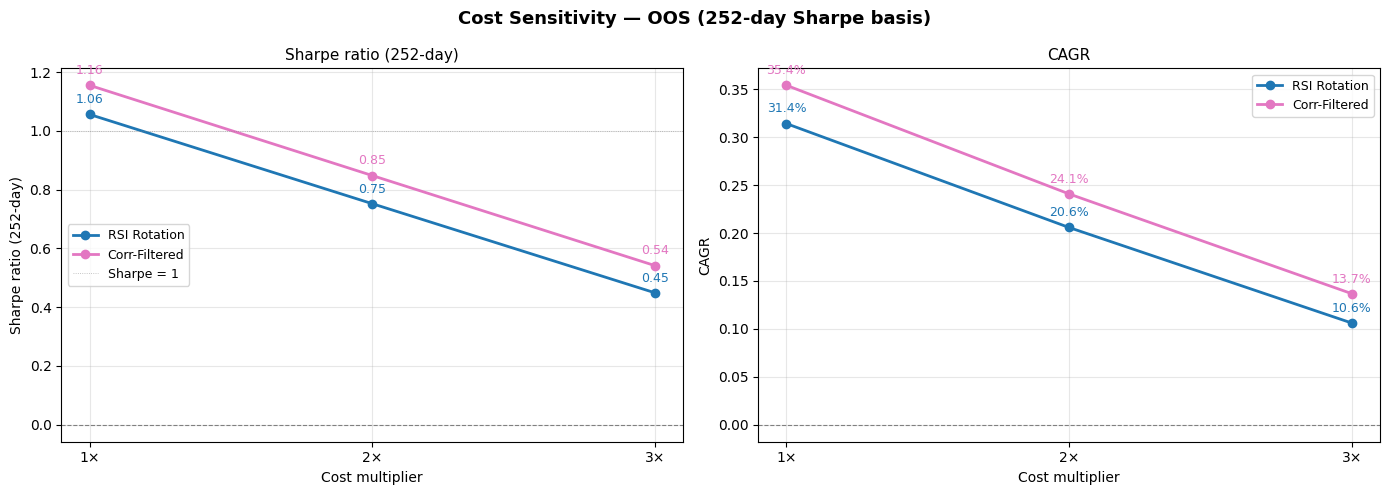

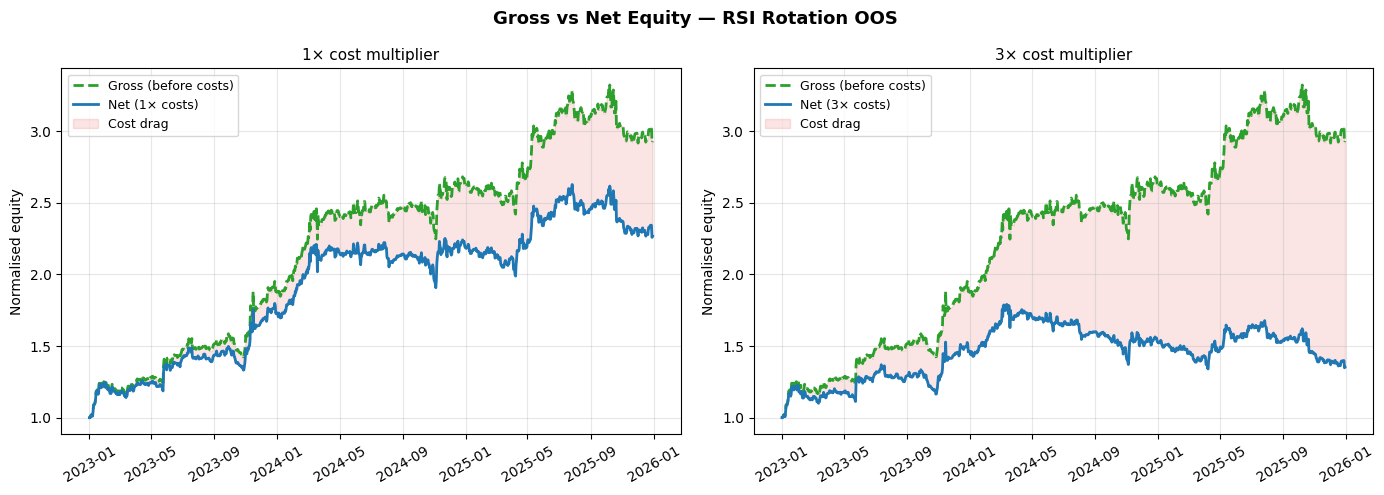

In [30]:
# Cell 15 — Transaction Cost Stress Test

COST_MULTIPLIERS = [1, 2, 3]

def build_portfolio_returns_with_cost_mult(weights_df, all_closes,
                                            crypto_tickers,
                                            tqqq_decay_per_day,
                                            cost_mult):
    """
    Identical to build_portfolio_returns but scales all transaction
    costs by cost_mult. Base costs come from one_way_cost() as defined
    in Cell 1 — this function never modifies that definition.
    """
    common_idx = weights_df.index
    ret_df_local = pd.DataFrame(index=common_idx,
                                columns=weights_df.columns, dtype=float)
    for ticker in weights_df.columns:
        if ticker in all_closes:
            ret_df_local[ticker] = (
                all_closes[ticker].reindex(common_idx).pct_change()
            )
    ret_df_local = ret_df_local.fillna(0.0)

    gross_ret      = (weights_df * ret_df_local).sum(axis=1)
    weight_changes = weights_df.diff().abs().fillna(0)

    cost_series = pd.Series(0.0, index=common_idx)
    for ticker in weights_df.columns:
        cost_series += (
            weight_changes[ticker] * one_way_cost(ticker) * cost_mult
        )

    if 'TQQQ' in weights_df.columns:
        cost_series += (
            weights_df['TQQQ'] * tqqq_decay_per_day * cost_mult
        )

    net_ret = gross_ret - cost_series
    return net_ret, gross_ret, cost_series


print('Running cost stress test...\n')
print(f'  Strategies tested : RSI Rotation (original), Corr-Filtered')
print(f'  Cost multipliers  : {COST_MULTIPLIERS}')
print(f'  Evaluation period : OOS ({OOS_START} → {OOS_END})\n')

stress_records = []

for mult in COST_MULTIPLIERS:
    for weights, label_base in [
        (weights_df,      'RSI Rotation'),
        (weights_corr_df, 'Corr-Filtered'),
    ]:
        net, gross, costs = build_portfolio_returns_with_cost_mult(
            weights, all_closes, CRYPTO_TICKERS,
            TQQQ_DECAY_BPS_PER_DAY, cost_mult=mult
        )

        net_oos  = net[oos_mask]
        eq_oos   = (1 + net_oos).cumprod()
        gross_oos = gross[oos_mask]
        eq_gross  = (1 + gross_oos).cumprod()

        m = full_metrics(net_oos, eq_oos,
                         label=f'{label_base} {mult}× costs', adpy=252)

        # Gross Sharpe at this multiplier (costs zeroed out)
        m_gross = full_metrics(gross_oos, eq_gross,
                               label='gross', adpy=252)

        stress_records.append({
            'Strategy'     : label_base,
            'Cost mult'    : f'{mult}×',
            'CAGR (net)'   : m['CAGR'],
            'Sharpe (net)' : m['Sharpe'],
            'MaxDD'        : m['MaxDD'],
            'Calmar'       : m['Calmar'],
            'CAGR (gross)' : m_gross['CAGR'],    # same for all mult rows
            'Sharpe (gross)': m_gross['Sharpe'],  # same for all mult rows
            'Total cost drag': costs[oos_mask].sum(),
        })

stress_df = pd.DataFrame(stress_records)

print('═' * 70)
print('COST SENSITIVITY TABLE — OOS (Sharpe: 252-day basis)')
print('═' * 70)

display_df = (
    stress_df
    .set_index(['Strategy', 'Cost mult'])
    [[
        'CAGR (gross)', 'Sharpe (gross)',
        'CAGR (net)',   'Sharpe (net)',
        'MaxDD',        'Calmar',
        'Total cost drag'
    ]]
    .copy()
)

display_df['CAGR (gross)']     = display_df['CAGR (gross)'].map('{:.1%}'.format)
display_df['Sharpe (gross)']   = display_df['Sharpe (gross)'].map('{:.2f}'.format)
display_df['CAGR (net)']       = display_df['CAGR (net)'].map('{:.1%}'.format)
display_df['Sharpe (net)']     = display_df['Sharpe (net)'].map('{:.2f}'.format)
display_df['MaxDD']            = display_df['MaxDD'].map('{:.1%}'.format)
display_df['Calmar']           = display_df['Calmar'].map('{:.2f}'.format)
display_df['Total cost drag']  = display_df['Total cost drag'].map('{:.1%}'.format)

display(display_df)

# ── Chart: Sharpe and CAGR decay across multipliers ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cost Sensitivity — OOS (252-day Sharpe basis)',
             fontsize=13, fontweight='bold')

colors   = {'RSI Rotation': '#1f77b4', 'Corr-Filtered': '#e377c2'}
x_labels = [f'{m}×' for m in COST_MULTIPLIERS]

for ax, metric, ylabel in [
    (axes[0], 'Sharpe (net)', 'Sharpe ratio (252-day)'),
    (axes[1], 'CAGR (net)',   'CAGR'),
]:
    for strategy, color in colors.items():
        rows = stress_df[stress_df['Strategy'] == strategy]
        y    = rows[metric].values
        ax.plot(x_labels, y, marker='o', color=color,
                linewidth=2, label=strategy)
        for xi, yi in zip(x_labels, y):
            fmt = f'{yi:.2f}' if 'Sharpe' in metric else f'{yi:.1%}'
            ax.annotate(fmt, (xi, yi),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=9, color=color)

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    if 'Sharpe' in metric:
        ax.axhline(1, color='gray', linewidth=0.6,
                   linestyle=':', alpha=0.6, label='Sharpe = 1')
    ax.set_title(ylabel, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Cost multiplier')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Gross vs net equity curves at 1× and 3× ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gross vs Net Equity — RSI Rotation OOS',
             fontsize=13, fontweight='bold')

for ax, mult in zip(axes, [1, 3]):
    net, gross, _ = build_portfolio_returns_with_cost_mult(
        weights_df, all_closes, CRYPTO_TICKERS,
        TQQQ_DECAY_BPS_PER_DAY, cost_mult=mult
    )
    net_oos   = net[oos_mask]
    gross_oos = gross[oos_mask]

    eq_net   = (1 + net_oos).cumprod()
    eq_gross = (1 + gross_oos).cumprod()
    eq_net   = eq_net   / eq_net.iloc[0]
    eq_gross = eq_gross / eq_gross.iloc[0]

    ax.plot(eq_gross.index, eq_gross.values,
            color='#2ca02c', linewidth=2.0,
            linestyle='--', label='Gross (before costs)')
    ax.plot(eq_net.index, eq_net.values,
            color='#1f77b4', linewidth=2.0,
            label=f'Net ({mult}× costs)')
    ax.fill_between(eq_gross.index,
                    eq_gross.values, eq_net.values,
                    color='#d62728', alpha=0.12, label='Cost drag')
    ax.set_title(f'{mult}× cost multiplier', fontsize=11)
    ax.set_ylabel('Normalised equity')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()